# TOP-opener classification: full exploration, on v1+v2 (95 protocols)

This notebook supersedes
`../run_history/top_change_classification_2026-09-24_v1only_47protocols.ipynb` (the v1-only
run) as the canonical version -- same systematic exploration (majority baseline, rule-based
baseline, Naive Bayes, n-gram sweeps, TF-IDF ablation, word+char union,
elastic net, C-tuning, BERT), re-run on the combined v1+v2 annotation batch
(95 protocols, up from 47) instead of v1 alone.

In [1]:
import sys
import numpy as np
import pandas as pd

sys.path.insert(0, "../../preprocessing") # add path to preprocessing folder, first pos
sys.path.insert(0, "../..")

## Load and merge v1 + v2

Two disjoint annotation batches (0 protocol overlap), each needing the same
key-based merge (not positional -- the annotator app writes labels in
labeling order, not input-file order).

`start_pos`/`end_pos` are each paragraph's `protocol_position` (its sequential
position within the protocol, assigned upstream when the protocol was parsed)
-- not a character offset. In these two CSVs, exported one row per raw `pre`
paragraph, `start_pos == end_pos` always. They only diverge below, once
paragraphs are joined into multi-paragraph contributions and `end_pos` becomes
the last paragraph's position in the group.

In [2]:
DATA_DIR = "../../labelling"

parts = []
for label_path, content_path in [
    (f"{DATA_DIR}/top_boundaries_opener_labels.csv", f"{DATA_DIR}/top_boundaries_annotation_input.csv"),
    (f"{DATA_DIR}/top_boundaries_opener_labels_v2.csv", f"{DATA_DIR}/top_boundaries_annotation_input_v2.csv"),
]:
    labels_df = pd.read_csv(label_path)
    content_df = pd.read_csv(content_path)
    new_cols = labels_df.columns.difference(content_df.columns) # compar column Index
    merged = content_df.merge(
        labels_df[["protocol_id", "start_pos", *new_cols]],
        on=["protocol_id", "start_pos"], how="left", validate="one_to_one", # unique keys
    )
    parts.append(merged)

result_df = pd.concat(parts, ignore_index=True) # new index
n_missing = result_df["is_opener"].isna().sum()
print(f"Rows missing a gold label: {n_missing} (dropped)")
result_df = result_df[result_df["is_opener"].notna()].reset_index(drop=True)
print("Shape:", result_df.shape)
print("Protocols:", result_df["protocol_id"].nunique())
print("Columns:", result_df.columns.tolist())
result_df.head(5)

Rows missing a gold label: 0 (dropped)
Shape: (25081, 12)
Protocols: 95
Columns: ['protocol_id', 'state', 'date', 'url', 'start_pos', 'end_pos', 'content', 'is_opener', 'notes', 'sponsor', 'topic', 'type']


,protocol_id,state,date,url,start_pos,end_pos,content,is_opener,notes,sponsor,topic,type
0,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,1,1,Meine sehr geehrten Damen und Herren! Liebe Ko...,1,Fortsetzung der 2. Lesung des Gesetzes über di...,NaN,Haushalt,NaN
1,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,2,2,Gesetz über die Feststellung des Haushaltsplan...,0,Einzelpläne einzelner Ministerien. Doch alles ...,NaN,NaN,NaN
2,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,3,3,Ich rufe auf:,0,NaN,NaN,NaN,NaN
3,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,4,4,Einzelplan 08 - Ministerium für Wirtschaft,1,NaN,NaN,Haushalt,Einzelplan
4,bb_4_14,bb,2005-05-19,https://assets.stateparl.de/protocols/bb_4_14.pdf,5,5,Beschlussempfehlung und Bericht des Ausschusse...,0,NaN,NaN,NaN,NaN


### Share of `pre` paragraphs per protocol

`result_df` already contains only `pre`-type paragraphs (filtered upstream, before this
notebook) -- there's no `type` column here to count "pre vs. other" directly. The proxy: within
each protocol, `end_pos` is the paragraph's position in the *whole* protocol (all types), so the
highest `end_pos` among this protocol's `pre` rows approximates the protocol's total paragraph
count, **assuming the protocol's last paragraph is itself a `pre` row often enough for this not
to systematically undercount** -- worth a sanity check once real numbers are in: if most ratios
come out implausibly close to 1.0, that assumption is being violated a lot and this needs a
different denominator (e.g. from the raw, unfiltered protocol XML/source instead).

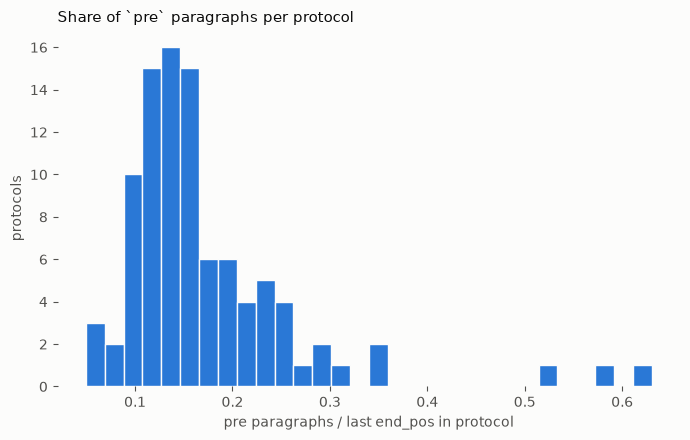

Mean pre-ratio: 0.173, median: 0.147


In [3]:
import matplotlib.pyplot as plt
from utils.colors import NAVY, CHROME

pre_paragraph_ratio = (
    result_df.groupby("protocol_id")
    .agg(n_pre_paragraphs=("start_pos", "size"), last_pos=("end_pos", "max"))
)
pre_paragraph_ratio["pre_ratio"] = pre_paragraph_ratio["n_pre_paragraphs"] / pre_paragraph_ratio["last_pos"]

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])
ax.hist(pre_paragraph_ratio["pre_ratio"], bins=30, color=NAVY, edgecolor=CHROME["surface_light"])
ax.set_xlabel("pre paragraphs / last end_pos in protocol", color=CHROME["ink_secondary"])
ax.set_ylabel("protocols", color=CHROME["ink_secondary"])
ax.set_title("Share of `pre` paragraphs per protocol", color=CHROME["ink_primary"], fontsize=11, loc="left")
ax.tick_params(colors=CHROME["ink_secondary"])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

print(f"Mean pre-ratio: {pre_paragraph_ratio['pre_ratio'].mean():.3f}, "
      f"median: {pre_paragraph_ratio['pre_ratio'].median():.3f}")

## Join consecutive `pre` paragraphs into contributions

Per `labelling/top_boundaries_annotation_conventions.md`, consecutive `pre` paragraphs within
a protocol with no gap in `start_pos` are one continuous chair utterance and
should be joined into a single text unit before classification.

### Optional: bridge nsc-only gaps

By default (`BRIDGE_NSC_GAPS = False`), two `pre` paragraphs join into one contribution only if
they're literally back-to-back in the raw protocol (no other row of any kind in between).

Set `BRIDGE_NSC_GAPS = True` to also join across a gap when *every* paragraph skipped in it is
`nsc` (an interjection -- not a real speaker's turn): the chair's utterance was merely
interrupted, not followed by someone else's contribution, so it's still one continuous chair
utterance per `labelling/top_boundaries_annotation_conventions.md`. A gap containing any non-nsc
row (a party/gov speaker) still breaks the contribution either way, regardless of this switch --
checked against the real affiliation sequence, not just against `pre` rows.

In [4]:
BRIDGE_NSC_GAPS = True  # False: only literally consecutive pre paragraphs join (old behavior)
                          # True: also join across gaps made up entirely of nsc rows

if BRIDGE_NSC_GAPS:
    from nsc_rule_parser import get_data_root

    raw_paragraphs_path = get_data_root() / "raw" / "stateparl_v3_parquet" / "stateparl_v3_paragraphs.parquet"
    protocol_ids = result_df["protocol_id"].unique().tolist()
    nsc_positions = pd.read_parquet(
        raw_paragraphs_path, columns=["protocol_id", "protocol_position", "affiliation"],
        filters=[("affiliation", "==", "nsc"), ("protocol_id", "in", protocol_ids)],
    )
    nsc_by_protocol = {
        pid: np.sort(g["protocol_position"].to_numpy())
        for pid, g in nsc_positions.groupby("protocol_id")
    }
    print(f"Loaded {len(nsc_positions)} nsc paragraphs across {len(nsc_by_protocol)} protocols")

Loaded 39832 nsc paragraphs across 95 protocols


In [5]:
paragraphs = result_df.sort_values(["protocol_id", "start_pos"]).reset_index(drop=True)

same_protocol = paragraphs["protocol_id"] == paragraphs["protocol_id"].shift()
prev_pos = paragraphs["start_pos"].shift()

if BRIDGE_NSC_GAPS:
    def gap_is_all_nsc(protocol_id, prev_pos, cur_pos):
        """True if every paragraph strictly between prev_pos and cur_pos is an nsc row (an
        interjection), not a real speaker's turn -- i.e. this gap is safe to bridge."""
        gap_len = cur_pos - prev_pos - 1
        if gap_len <= 0:
            return gap_len == 0 # 0 = already consecutive; negative shouldn't happen
        arr = nsc_by_protocol.get(protocol_id, np.empty(0, dtype=int))
        lo, hi = np.searchsorted(arr, [prev_pos + 1, cur_pos])
        return (hi - lo) == gap_len

    is_consecutive = pd.Series(False, index=paragraphs.index)
    is_consecutive[same_protocol] = [
        gap_is_all_nsc(pid, pp, cp)
        for pid, pp, cp in zip(
            paragraphs.loc[same_protocol, "protocol_id"],
            prev_pos[same_protocol],
            paragraphs.loc[same_protocol, "start_pos"],
        )
    ]
    n_bridged = int((is_consecutive & same_protocol & (paragraphs["start_pos"] != prev_pos + 1)).sum())
    print(f"Bridged {n_bridged} nsc-only gaps that would otherwise have broken a contribution")
else:
    is_consecutive = same_protocol & (paragraphs["start_pos"] == prev_pos + 1)

is_new_contribution = ~is_consecutive # boundary: new protocol, real speaker in between, or (if not bridging) any gap
paragraphs["contribution_seq"] = is_new_contribution.cumsum() # boundary-based grouping

def first_nonempty(s):
    vals = [v for v in s if pd.notna(v) and str(v).strip()]
    return vals[0] if vals else pd.NA

# `sponsor` uses two spellings for the same entity across the corpus ("Landesregierung"
# vs "gov", never mixed within one contribution) -- canonicalize before picking.
SPONSOR_MAP = {"Landesregierung": "gov"}

def canonicalize_sponsor(s):
    if pd.isna(s):
        return s
    return "; ".join(SPONSOR_MAP.get(t.strip(), t.strip()) for t in str(s).split(";"))

paragraphs["sponsor"] = paragraphs["sponsor"].apply(canonicalize_sponsor)

# `type` is multi-label ("; "-joined, source-text order). Per
# `labelling/top_boundaries_annotation_conventions.md`, is_opener and type/sponsor/topic are
# independent judgments -- type/sponsor/topic get recorded on whichever row
# actually prints them (often a citation line trailing the opener row, not the
# opener row itself), so collect from every row in the contribution, not just
# opener rows.
def type_labels(s):
    labels = []
    for v in s.dropna():
        for t in str(v).split(";"):
            t = t.strip()
            if t and t not in labels:
                labels.append(t)
    return labels

contributions = paragraphs.groupby("contribution_seq").agg(
    protocol_id=("protocol_id", "first"),
    state=("state", "first"),
    date=("date", "first"),
    url=("url", "first"),
    start_pos=("start_pos", "min"),
    end_pos=("end_pos", "max"),
    n_paragraphs=("start_pos", "size"),
    content=("content", lambda s: "\n".join(s)),
    is_opener=("is_opener", "max"),
    types=("type", type_labels), # all retained across rows
    sponsor=("sponsor", first_nonempty), # ggf. multiple sponsors across rows, but only one retained
    topic=("topic", first_nonempty), # ggf. multiple topics across rows/openers, but only one retained
).reset_index(drop=True)

contributions["contribution_id"] = (
    contributions["protocol_id"] + "_" + contributions["start_pos"].astype(str)
    + "-" + contributions["end_pos"].astype(str)
)

print(f"{len(paragraphs)} pre paragraphs -> {len(contributions)} contributions")
print(f"Contributions spanning >1 paragraph: {(contributions['n_paragraphs'] > 1).sum()}")
contributions.head(5)

Bridged 2214 nsc-only gaps that would otherwise have broken a contribution


25081 pre paragraphs -> 9249 contributions
Contributions spanning >1 paragraph: 2054


,protocol_id,state,date,url,start_pos,end_pos,n_paragraphs,content,is_opener,types,sponsor,topic,contribution_id
0,bb_3_100,bb,2004-08-26,https://assets.stateparl.de/protocols/bb_3_100...,1,16,13,"Meine Damen und Herren, ich wünsche Ihnen zu B...",1,"[Beschlussempfehlung, Bericht]",Ausschuss,Prozedural,bb_3_100_1-16
1,bb_3_100,bb,2004-08-26,https://assets.stateparl.de/protocols/bb_3_100...,74,76,2,"Herr Abgeordneter, bitte kommen Sie zum Schlus...",0,[],NaN,NaN,bb_3_100_74-76
2,bb_3_100,bb,2004-08-26,https://assets.stateparl.de/protocols/bb_3_100...,83,83,1,Das Wort erhält der Vertreter der PDS-Fraktion...,0,[],NaN,NaN,bb_3_100_83-83
3,bb_3_100,bb,2004-08-26,https://assets.stateparl.de/protocols/bb_3_100...,121,121,1,"Das Wort erhält die Fraktion der SPD, für die ...",0,[],NaN,NaN,bb_3_100_121-121
4,bb_3_100,bb,2004-08-26,https://assets.stateparl.de/protocols/bb_3_100...,161,161,1,Das Wort erhält die DVU-Fraktion. Für sie spri...,0,[],NaN,NaN,bb_3_100_161-161


## Revert: broadcast contribution-level predictions back to paragraphs

Run a classifier on `contributions["content"]`, then use `revert_to_paragraphs`
to attach that prediction to every paragraph inside the contribution's
`[start_pos, end_pos]` range.

In [6]:
def revert_to_paragraphs(contribution_predictions, paragraph_df, pred_cols):
    exploded = contribution_predictions[["protocol_id", "start_pos", "end_pos", *pred_cols]].copy()
    exploded["start_pos"] = exploded.apply(
        lambda r: list(range(int(r["start_pos"]), int(r["end_pos"]) + 1)), axis=1
    )
    exploded = exploded.explode("start_pos").drop(columns="end_pos")
    return paragraph_df.drop(columns=pred_cols, errors="ignore").merge(
        exploded, on=["protocol_id", "start_pos"], how="left", validate="one_to_one",
    )

reverted = revert_to_paragraphs(contributions, paragraphs, ["is_opener"])
expected = paragraphs.groupby("contribution_seq")["is_opener"].transform("max")
mismatches = (reverted["is_opener"].values != expected.values).sum()
print(f"Round-trip mismatches: {mismatches} (expect 0)")

Round-trip mismatches: 0 (expect 0)


## Exploratory data analysis

Placed here, right after the revert-to-paragraphs cell and before the protocol-level test split
below, so everything in this section runs on `contributions` -- the full merged v1+v2 dataset,
prior to any cv_pool/test split (`cv_pool` doesn't exist yet at this point in the notebook; if a
cv_pool-only version of any of this becomes useful later, rerun after the split cell below).

Token counts use the same tokenizer as the n-gram vectorizers further down --
`CountVectorizer().build_analyzer()`, sklearn's default: lowercase, then split on runs of 2+
word characters (drops punctuation and single-character tokens) -- not a naive `.split()`.

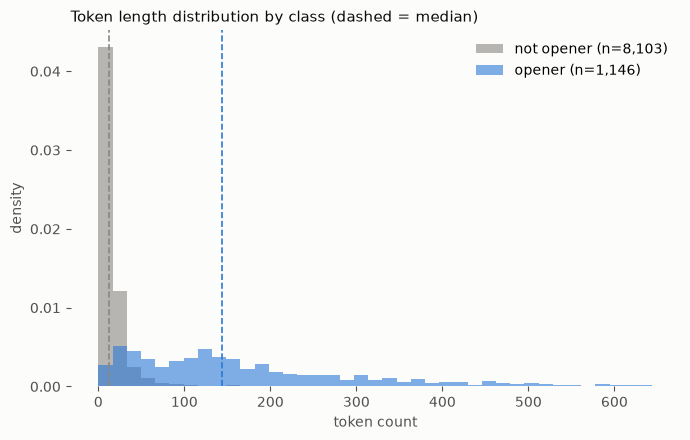

In [7]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from utils.colors import NAVY, CHROME

tokenizer = CountVectorizer().build_analyzer()
token_lengths = contributions["content"].apply(lambda s: len(tokenizer(s)))
not_opener_lengths = token_lengths[contributions["is_opener"] == 0]
opener_lengths = token_lengths[contributions["is_opener"] == 1]

# density-normalized (not raw counts): openers are the minority class, so raw-count histograms
# would make the opener bars look negligible regardless of shape. Capped at the 99th percentile
# so the long right tail doesn't compress the bulk of the distribution into a sliver.
x_max = token_lengths.quantile(0.99)
bins = np.linspace(0, x_max, 40)

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])
ax.hist(not_opener_lengths, bins=bins, density=True, color=CHROME["ink_muted"], alpha=0.6,
        label=f"not opener (n={len(not_opener_lengths):,})")
ax.hist(opener_lengths, bins=bins, density=True, color=NAVY, alpha=0.6,
        label=f"opener (n={len(opener_lengths):,})")
ax.axvline(not_opener_lengths.median(), color=CHROME["ink_muted"], ls="--", lw=1.2)
ax.axvline(opener_lengths.median(), color=NAVY, ls="--", lw=1.2)
ax.set_xlabel("token count", color=CHROME["ink_secondary"])
ax.set_ylabel("density", color=CHROME["ink_secondary"])
ax.set_title("Token length distribution by class (dashed = median)", color=CHROME["ink_primary"],
             fontsize=11, loc="left")
ax.tick_params(colors=CHROME["ink_secondary"])
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

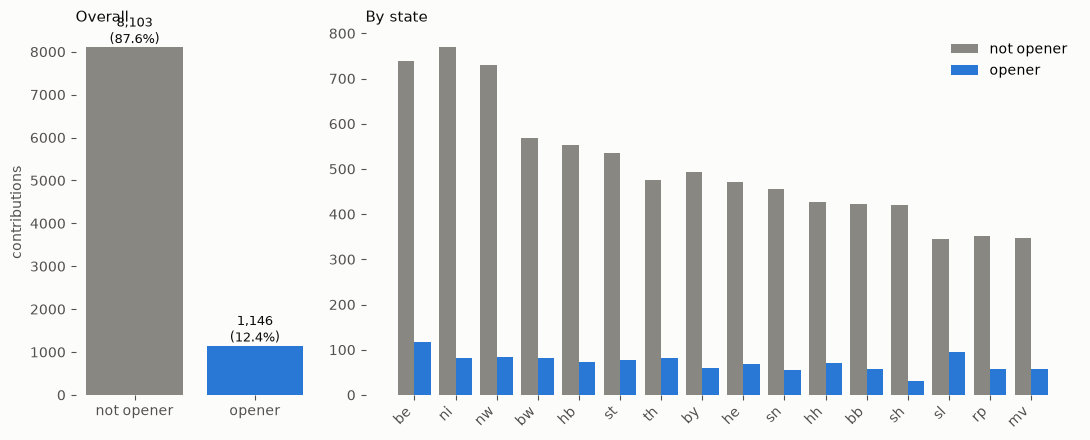

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=CHROME["surface_light"],
                          gridspec_kw={"width_ratios": [1, 3]})
for ax in axes:
    ax.set_facecolor(CHROME["surface_light"])
    ax.tick_params(colors=CHROME["ink_secondary"])
    for spine in ax.spines.values():
        spine.set_visible(False)

counts = contributions["is_opener"].value_counts().reindex([0, 1])
total = counts.sum()
ax = axes[0]
bars = ax.bar(["not opener", "opener"], counts, color=[CHROME["ink_muted"], NAVY])
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}\n({100 * c / total:.1f}%)",
            ha="center", va="bottom", color=CHROME["ink_primary"], fontsize=9)
ax.set_title("Overall", color=CHROME["ink_primary"], fontsize=11, loc="left")
ax.set_ylabel("contributions", color=CHROME["ink_secondary"])

by_state = contributions.groupby(["state", "is_opener"]).size().unstack(fill_value=0).reindex(columns=[0, 1])
by_state = by_state.loc[by_state.sum(axis=1).sort_values(ascending=False).index]
ax = axes[1]
x = np.arange(len(by_state))
width = 0.4
ax.bar(x - width / 2, by_state[0], width, color=CHROME["ink_muted"], label="not opener")
ax.bar(x + width / 2, by_state[1], width, color=NAVY, label="opener")
ax.set_xticks(x)
ax.set_xticklabels(by_state.index, color=CHROME["ink_secondary"], rotation=45, ha="right")
ax.set_title("By state", color=CHROME["ink_primary"], fontsize=11, loc="left")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

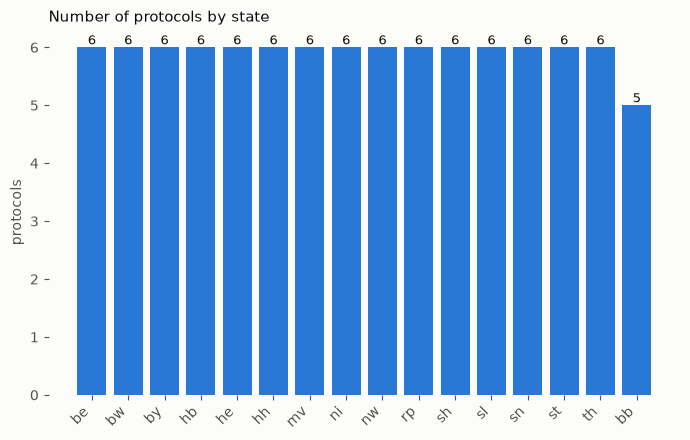

In [9]:
protocols_by_state = contributions.groupby("state")["protocol_id"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])
ax.bar(protocols_by_state.index, protocols_by_state.values, color=NAVY)
for i, v in enumerate(protocols_by_state.values):
    ax.text(i, v, str(v), ha="center", va="bottom", color=CHROME["ink_primary"], fontsize=9)
ax.set_ylabel("protocols", color=CHROME["ink_secondary"])
ax.set_title("Number of protocols by state", color=CHROME["ink_primary"], fontsize=11, loc="left")
ax.tick_params(colors=CHROME["ink_secondary"])
plt.xticks(rotation=45, ha="right")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
# One row per protocol first -- date is protocol-constant, and contributions has many rows
# per protocol, so counting from contributions directly would weight years by contribution
# volume rather than by how many protocols/sessions actually occurred.
protocol_dates = contributions.drop_duplicates("protocol_id")["date"]
protocol_years = pd.to_datetime(protocol_dates, errors="coerce").dt.year
n_unparsed = protocol_years.isna().sum()
if n_unparsed:
    print(f"Warning: {n_unparsed} protocols had an unparseable date, excluded below.")
print(f"{protocol_years.notna().sum()} protocols span {int(protocol_years.min())}-{int(protocol_years.max())}.")
print(protocol_years.value_counts().sort_index())

95 protocols span 2000-2025.
date
2000    2
2001    4
2002    2
2004    3
2005    6
2006    7
2007    1
2008    2
2009    4
2010    3
2011    2
2012    3
2013    8
2014    6
2015    4
2016    5
2017    3
2018    3
2019    3
2020    2
2021    9
2022    6
2023    1
2024    5
2025    1
Name: count, dtype: int64


## Protocol-level test split

Hold out one protocol per state as a fixed test set, guaranteeing all 16
states are represented regardless of the random draw. This yields 16 of 95 
protocols (16.8%) and 2,130 of 11,463 contribution-level observations (18.6%). 
The rest forms a CV pool for grouped k-fold cross-validation, grouped by 
`protocol_id` so no contribution from the same protocol appears on both sides 
of a fold.

In [11]:
rng = np.random.default_rng(20260921)

protocols_meta = contributions[["protocol_id", "state"]].drop_duplicates().reset_index(drop=True)

test_protocols = set()
for state, group in protocols_meta.groupby("state"):
    pick = group.sample(1, random_state=rng.integers(1_000_000))["protocol_id"].iloc[0]
    test_protocols.add(pick)

contributions["split"] = np.where(contributions["protocol_id"].isin(test_protocols), "test", "cv_pool")
print(f"Test protocols: {len(test_protocols)} (1 per state, {protocols_meta['state'].nunique()} states)\n")

split_summary = (
    contributions["split"]
    .value_counts()
    .to_frame("n_contributions")
    .assign(percent=lambda x: 100 * x["n_contributions"] / x["n_contributions"].sum())
)

print(split_summary.round(1))

Test protocols: 16 (1 per state, 16 states)

         n_contributions  percent
split                            
cv_pool             7541     81.5
test                1708     18.5


**Effect of `BRIDGE_NSC_GAPS` on this split** (checked directly, both settings, before deciding
which to use): the 16 test protocols themselves are identical either way -- that selection only
depends on `(protocol_id, state)`, never on contribution count -- so switching this flag mid-project
does not change which protocols are held out. Total rows and class balance do shift, since bridging
merges some previously-separate contributions into one:

| | `BRIDGE_NSC_GAPS=False` | `BRIDGE_NSC_GAPS=True` |
|---|---|---|
| total contributions | 11,463 | 9,249 |
| cv_pool / test | 9,333 / 2,130 | 7,541 / 1,708 |
| openers (total) | 1,306 | 1,146 |
| prevalence (cv_pool) | 11.41% | 12.40% |

Every baseline/sweep/tuning result further down reflects whichever setting was active when it was
last run -- switching this flag means a full rerun, not just this cell, to keep results consistent
with the current contribution segmentation.

## Chance baselines, judged on the opener class (class 1)

F1 is read on the minority class only. Three trivial references:

- **Always predict opener** (minority-class baseline): recall is 1, precision
  equals the prevalence `p`, so F1 = 2p/(1+p). This is the hardest trivial F1
  floor, since it gets full recall for free.
- **Stratified random**: predict "opener" at rate `p`. Precision stays at `p`,
  recall is `p`, so F1 = `p`.
- **Always predict not-opener** (majority class): F1 is 0, so it is not a real
  yardstick. Listed only to show why binary F1 needs the two above.

Macro-F1, MCC, PR-AUC and ROC-AUC are reported alongside, since MCC and
ROC-AUC have universal floors (0 and 0.5) and PR-AUC's floor is `p`.

They are computed on `cv_pool` here so they sit next to the CV scores below. The
held-out test split is not touched until the final section at the end.

In [12]:
from sklearn.metrics import (
    precision_recall_fscore_support, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
)

cv_pool_contributions = contributions[contributions["split"] == "cv_pool"]

y_true = cv_pool_contributions["is_opener"]
prevalence = y_true.mean()
print(f"cv_pool opener prevalence: {prevalence:.3f}")

rng = np.random.default_rng(20260921)
chance_baselines = {
    "always opener (minority)": pd.Series(1, index=y_true.index),
    "stratified random":        pd.Series((rng.random(len(y_true)) < prevalence).astype(int), index=y_true.index),
    "always not-opener":        pd.Series(0, index=y_true.index),
}

for name, y_pred in chance_baselines.items():
    p_c, r_c, f_c, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    p, r, f1 = p_c[1], r_c[1], f_c[1]
    macro_f1 = (f_c[0] + f_c[1]) / 2
    print(f"{name:26s} F1={f1:.3f} Macro-F1={macro_f1:.3f} Acc={accuracy_score(y_true, y_pred):.3f} "
          f"| open P={p:.3f} R={r:.3f} | not P={p_c[0]:.3f} R={r_c[0]:.3f} F1={f_c[0]:.3f} "
          f"| ROC-AUC={roc_auc_score(y_true, y_pred):.3f} "
          f"PR-AUC={average_precision_score(y_true, y_pred):.3f} MCC={matthews_corrcoef(y_true, y_pred):.3f}")

print(f"\nAnalytic check: always-opener F1 = 2p/(1+p) = {2 * prevalence / (1 + prevalence):.3f}, "
      f"stratified-random F1 = p = {prevalence:.3f}")

cv_pool opener prevalence: 0.124
always opener (minority)   F1=0.221 Macro-F1=0.110 Acc=0.124 | open P=0.124 R=1.000 | not P=0.000 R=0.000 F1=0.000 | ROC-AUC=0.500 PR-AUC=0.124 MCC=0.000
stratified random          F1=0.117 Macro-F1=0.496 Acc=0.781 | open P=0.117 R=0.117 | not P=0.875 R=0.875 F1=0.875 | ROC-AUC=0.496 PR-AUC=0.123 MCC=-0.008
always not-opener          F1=0.000 Macro-F1=0.467 Acc=0.876 | open P=0.000 R=0.000 | not P=0.876 R=1.000 F1=0.934 | ROC-AUC=0.500 PR-AUC=0.124 MCC=0.000

Analytic check: always-opener F1 = 2p/(1+p) = 0.221, stratified-random F1 = p = 0.124


Openers now make up **12.4% of reconstructed blocks** in the CV pool, up from 11.4% under the previous contribution definition, which did not bridge `nsc` interruptions. Joining across `nsc` gaps changed the observation unit, so the baselines must be recalculated for the new block-level dataset.

- The **stratified-random** baseline has the highest macro-F1 of the three trivial baselines in this run, at **0.496**. It predicts opener labels at approximately the observed prevalence without reliably identifying actual openers: opener precision, recall, and F1 are each 0.117; ROC-AUC is 0.496, PR-AUC is 0.123, and MCC is −0.008. Its departure from the theoretical opener F1 of approximately 0.124 reflects a finite random draw.
- The **always-not-opener** baseline achieves macro-F1 of **0.467** and accuracy of 0.876 because non-openers are the majority. It misses every opener, giving opener precision, recall, and F1 of 0.
- The **always-opener** baseline achieves macro-F1 of **0.110**. It finds every opener (recall = 1.000), but its precision equals the opener prevalence, 0.124; opener F1 is 0.221 and accuracy is 0.124. Its nonzero opener F1 does not indicate discrimination: ROC-AUC is 0.500, PR-AUC is 0.124, and MCC is 0.

A useful classifier should **clearly exceed macro-F1 = 0.496**, the strongest trivial baseline on the primary metric. Opener precision and recall should be reported alongside macro-F1 to show whether the model actually detects openers rather than achieving a favorable aggregate score while neglecting them. PR-AUC of approximately 0.124, ROC-AUC of 0.500, and MCC of 0 provide additional chance-level reference points. These values apply to the **new reconstructed blocks**; the previous contribution-level baselines are not directly interchangeable with them.

## Another baseline that matters: the existing, vibe-coded, exploratory, rule-based detector

Majority-class F1 is analytically always exactly 0, so "improvement over
majority" is a tautology. The comparison that answers this project's real
question -- does an ML classifier beat what's already running in production --
is against `preprocessing/top_boundaries.py`'s `is_top_opener()` regex.

The rule is a per-paragraph detector, so it is applied to each paragraph and a
contribution counts as predicted opener if any of its paragraphs fires (the
same aggregation as the gold label). It needs no fitting, but is scored on the
same 5 grouped, stratified folds every model below is judged on -- its
predictions do not change fold to fold, only how they are aggregated -- so the
"... over rule-based detector" lines below stay a fold-for-fold comparison.
`cv_pool`, `X`, `y`, `groups` and `sgkf` are defined here and reused unchanged
from now on; the "Choosing k" section further down re-derives `sgkf`
explicitly as part of comparing 10-fold vs 5-fold, but with the same
parameters and seed it is the identical split.

In [13]:
from top_boundaries import is_top_opener
from sklearn.model_selection import StratifiedGroupKFold

# The rule is written for a single paragraph (its heading regex is anchored to the
# start of the text), so run it per paragraph and take the max within each
# contribution, the same way the gold label is aggregated. Running it on the joined
# text misses headings that sit inside a merged contribution.
paragraphs["rule_pred"] = paragraphs["content"].apply(is_top_opener)
contributions["rule_pred"] = paragraphs.groupby("contribution_seq")["rule_pred"].max().to_numpy()

cv_pool = contributions[contributions["split"] == "cv_pool"].reset_index(drop=True)
X = cv_pool["content"]
y = cv_pool["is_opener"]
groups = cv_pool["protocol_id"]
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=917)

rule_fold_p, rule_fold_r, rule_fold_f1, rule_fold_macro_f1, rule_fold_acc = [], [], [], [], []
rule_fold_p0, rule_fold_r0, rule_fold_f1_0 = [], [], []
rule_fold_roc_auc, rule_fold_pr_auc, rule_fold_mcc = [], [], []
for train_idx, val_idx in sgkf.split(X, y, groups):
    yval = y.iloc[val_idx]
    rpred = cv_pool["rule_pred"].iloc[val_idx]
    p_c, r_c, f_c, _ = precision_recall_fscore_support(yval, rpred, labels=[0, 1], zero_division=0)
    rule_fold_p.append(p_c[1]); rule_fold_r.append(r_c[1]); rule_fold_f1.append(f_c[1])
    rule_fold_p0.append(p_c[0]); rule_fold_r0.append(r_c[0]); rule_fold_f1_0.append(f_c[0])
    rule_fold_macro_f1.append((f_c[0] + f_c[1]) / 2)
    rule_fold_acc.append(accuracy_score(yval, rpred))
    rule_fold_roc_auc.append(roc_auc_score(yval, rpred))
    rule_fold_pr_auc.append(average_precision_score(yval, rpred))
    rule_fold_mcc.append(matthews_corrcoef(yval, rpred))

rule_fold_f1 = np.array(rule_fold_f1)
RULE_F1_CV = rule_fold_f1.mean()
RULE_MACRO_F1_CV = np.mean(rule_fold_macro_f1)
RULE_ACC_CV = np.mean(rule_fold_acc)
RULE_ROC_AUC = np.mean(rule_fold_roc_auc)
RULE_PR_AUC = np.mean(rule_fold_pr_auc)
RULE_MCC = np.mean(rule_fold_mcc)
print(f"Rule-based detector, 5-fold:         F1={RULE_F1_CV:.3f} +/- {rule_fold_f1.std(ddof=1):.3f} "
      f"Macro-F1={RULE_MACRO_F1_CV:.3f} Acc={RULE_ACC_CV:.3f} "
      f"| open P={np.mean(rule_fold_p):.3f} R={np.mean(rule_fold_r):.3f} "
      f"| not P={np.mean(rule_fold_p0):.3f} R={np.mean(rule_fold_r0):.3f} F1={np.mean(rule_fold_f1_0):.3f} "
      f"| ROC-AUC={RULE_ROC_AUC:.3f} PR-AUC={RULE_PR_AUC:.3f} MCC={RULE_MCC:.3f}")


def get_scores(fitted_pipe, X_subset):
    """decision_function if available -- LogisticRegression has one too (the raw linear score,
    pre-sigmoid), same as LinearSVC/SGD-hinge, so both go through this branch identically;
    only classifiers without one at all (e.g. MultinomialNB) fall back to predict_proba's
    positive-class column."""
    if hasattr(fitted_pipe, "decision_function"):
        return fitted_pipe.decision_function(X_subset)
    return fitted_pipe.predict_proba(X_subset)[:, 1]

Rule-based detector, 5-fold:         F1=0.679 +/- 0.071 Macro-F1=0.823 Acc=0.939 | open P=0.973 R=0.525 | not P=0.937 R=0.998 F1=0.966 | ROC-AUC=0.762 PR-AUC=0.571 MCC=0.689


The rule-based detector clears the trivial baselines by a wide margin on the reconstructed block-level CV pool. 

Its **macro-F1 is 0.823**, compared with 0.496 for the stratified-random baseline and 0.467 for always-not-opener. It also achieves opener F1 of 0.679, versus 0.221 for always-opener; MCC of 0.689, versus approximately 0 for the trivial baselines; ROC-AUC of 0.762, versus approximately 0.500; and PR-AUC of 0.571, versus the opener prevalence of approximately 0.124. These results show that the rule distinguishes openers from non-openers rather than merely exploiting class frequencies.

Its opener precision and recall remain uneven: **precision is 0.973, but recall is 0.525**. When the rule identifies an opener, it is usually correct; however, it misses nearly half of the true openers. This is consistent with a conservative, heading-anchored rule that catches formulaic announcements such as “ich rufe Tagesordnungspunkt N auf” but misses less literal phrasing.

Accuracy is 0.939 and not-opener F1 is 0.966, but non-openers account for 87.6% of the CV pool. **Macro-F1 is the primary comparison metric** for subsequent models; opener precision and recall show the rule’s practical trade-off, while MCC provides another measure of overall discrimination.

### Opener counts per fold

Checking `sgkf`'s class balance across folds directly, rather than assuming
`StratifiedGroupKFold` keeps it stable -- the group constraint (protocols never split
across train/val) competes with the stratification target, so this is worth seeing,
not just trusting.

In [14]:
print(f"cv_pool: {len(y)} contributions, {int(y.sum())} openers ({y.mean():.1%})")
for fold_i, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups), start=1):
    yval, ytr = y.iloc[val_idx], y.iloc[train_idx]
    print(f"  fold {fold_i}: val n={len(val_idx):4d}  openers={int(yval.sum()):3d} ({yval.mean():.1%})"
          f"   | train n={len(train_idx):4d}  openers={int(ytr.sum()):3d} ({ytr.mean():.1%})")

cv_pool: 7541 contributions, 935 openers (12.4%)
  fold 1: val n=1513  openers=189 (12.5%)   | train n=6028  openers=746 (12.4%)
  fold 2: val n=1519  openers=183 (12.0%)   | train n=6022  openers=752 (12.5%)
  fold 3: val n=1483  openers=190 (12.8%)   | train n=6058  openers=745 (12.3%)
  fold 4: val n=1506  openers=189 (12.5%)   | train n=6035  openers=746 (12.4%)
  fold 5: val n=1520  openers=184 (12.1%)   | train n=6021  openers=751 (12.5%)


The reconstructed CV pool contains **7,541 blocks, including 935 openers (12.4%)**. Across the five frozen outer folds, validation opener prevalence ranges from 12.0% to 12.8%, so the folds remain similar in class balance after reconstruction. These are the new block-level rule results; the previous contribution-level figures should not be used as its benchmark.

## Naive Bayes as first model

Multinomial NB on raw counts, word unigrams and char 3-5grams separately, as a
first check before the more careful word/char/TF-IDF exploration below.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support

# cv_pool, X, y, groups and sgkf are already set up two cells above.
nb_configs = {
    "word unigram counts": CountVectorizer(min_df=2),
    "char_wb 3-5gram counts": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 5)),
}

for name, vectorizer in nb_configs.items():
    fold_p, fold_r, fold_f1, fold_macro_f1, fold_acc = [], [], [], [], []
    fold_p0, fold_r0, fold_f1_0 = [], [], []
    fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
    for train_idx, val_idx in sgkf.split(X, y, groups):
        pipe = Pipeline([("vec", vectorizer), ("clf", MultinomialNB())])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipe.predict(X.iloc[val_idx])
        scores = get_scores(pipe, X.iloc[val_idx])
        yv = y.iloc[val_idx]
        p_c, r_c, f_c, _ = precision_recall_fscore_support(yv, preds, labels=[0, 1], zero_division=0)
        p, r, f1 = p_c[1], r_c[1], f_c[1]
        fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
        fold_p0.append(p_c[0]); fold_r0.append(r_c[0]); fold_f1_0.append(f_c[0])
        fold_macro_f1.append((f_c[0] + f_c[1]) / 2)
        fold_acc.append(accuracy_score(yv, preds))
        fold_roc_auc.append(roc_auc_score(yv, scores))
        fold_pr_auc.append(average_precision_score(yv, scores))
        fold_mcc.append(matthews_corrcoef(yv, preds))
    fold_f1 = np.array(fold_f1)
    print(f"NB, {name:24s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
          f"Macro-F1={np.mean(fold_macro_f1):.3f} Acc={np.mean(fold_acc):.3f} "
          f"| open P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
          f"| not P={np.mean(fold_p0):.3f} R={np.mean(fold_r0):.3f} F1={np.mean(fold_f1_0):.3f} "
          f"| ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
          f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)")

NB, word unigram counts      F1=0.811 +/- 0.077 Macro-F1=0.892 Acc=0.952 | open P=0.799 R=0.826 | not P=0.975 R=0.971 F1=0.973 | ROC-AUC=0.925 PR-AUC=0.786 MCC=0.785  (+0.132 F1 over rule-based detector)


NB, char_wb 3-5gram counts   F1=0.782 +/- 0.093 Macro-F1=0.875 Acc=0.944 | open P=0.763 R=0.804 | not P=0.972 R=0.965 F1=0.968 | ROC-AUC=0.896 PR-AUC=0.703 MCC=0.751  (+0.102 F1 over rule-based detector)


Both Naive Bayes configurations outperform the rule-based detector on the **macro-F1**: 

word-unigram counts score **0.892**, character \(3\)–\(5\)-gram counts score **0.875**, and the rule scores **0.823**. They also improve opener F1 to 0.811 and 0.782, respectively, versus 0.679 for the rule. The printed opener-F1 gains are +0.132 for word unigrams and +0.102 for character n-grams; the latter may differ by 0.001 from subtraction of the displayed rounded values.

Both NB models catch substantially more openers than the rule: opener recall rises to **0.826** for word unigrams and **0.804** for character n-grams, compared with **0.525** for the rule. That comes with lower opener precision—**0.799** and **0.763**, respectively, versus the rule’s **0.973**. Thus, NB trades some of the rule’s exceptionally low false-positive tendency for fewer missed openers. Whether that trade-off is desirable depends on the eventual use, but both NB models improve macro-F1 despite the precision loss.

Word unigrams outperform character n-grams on every reported metric: macro-F1 (**0.892 vs. 0.875**), opener F1 (**0.811 vs. 0.782**), ROC-AUC (**0.925 vs. 0.896**), PR-AUC (**0.786 vs. 0.703**), and MCC (**0.785 vs. 0.751**). This suggests that word-level information is more effective for these *standalone NB configurations*. It does not establish that character features are unhelpful when combined with words in a different classifier.

Finally, both NB configurations have higher ROC-AUC and PR-AUC than the rule’s reported **0.762** and **0.571**. Interpret that comparison cautiously **if** the rule’s AUCs were calculated from its hard 0/1 outputs while NB’s were calculated from continuous scores: the NB scores allow a ranking across thresholds, whereas hard rule predictions do not provide the same kind of ranking detail.

## Choosing k: 10-fold vs 5-fold

`cv_pool` has more protocols now (v1+v2), but still checking both once, same
BOW+LogReg pipeline, before settling on 5-fold for everything after. `sgkf`
itself was already defined above (same params, same `X`/`y`/`groups`, so the
same split); only `sgkf_10` is new here.

With scikit learn, deprecated since version 1.8: 
penalty was deprecated. 
Use l1_ratio and C instead. 

l1_ratio=0 for penalty='l2', l1_ratio=1 for penalty='l1', l1_ratio set to any float between 0 and 1 for penalty='elasticnet', and C=np.inf for penalty=None.

So in the following, we are doing the default, which is the inverse regularization strength of C=1.0 and l1_ratio=0.0. That's an L2 regularization.

`run_logreg_cv_sweep()` below factors out the loop every sweep cell from here through the
TF-IDF ablation runs: fit default-C `LogisticRegression(class_weight="balanced", max_iter=1000)`
over one or more vectorizer configs, on the same set of metrics. Each cell after this one is
just a `configs` dict and a one-line call. The unregularized/tuned elastic-net variants further
down are a different model per column, not just a different vectorizer, so they keep their own
loop rather than using this function.

In [16]:
from sklearn.linear_model import LogisticRegression

def run_logreg_cv_sweep(configs, splitter=None, track_vocab=False, show_rule_delta=True, width=18,
                         class_weight: str | dict | None = "balanced"):
    """CV sweep over one or more configs. Each configs[label] is either a bare vectorizer
    (fits LogisticRegression(class_weight=class_weight, max_iter=1000) internally, as every
    earlier sweep in this notebook does) or a (vectorizer, classifier) tuple (uses that exact
    classifier as-is -- class_weight is then whatever the classifier itself was built with, this
    parameter is ignored for that row; this is how the LogReg-vs-LinearSVC comparisons below
    work). Prints one line per entry. `splitter` defaults to the global `sgkf` (resolved at call
    time, not def time, so a later `sgkf = ...` rebind is picked up without having to redefine
    this function)."""
    if splitter is None:
        splitter = sgkf
    for name, value in configs.items():
        if isinstance(value, tuple):
            vectorizer, clf = value
        else:
            vectorizer, clf = value, LogisticRegression(class_weight=class_weight, max_iter=1000)
        fold_p, fold_r, fold_f1, fold_macro_f1, fold_acc = [], [], [], [], []
        fold_p0, fold_r0, fold_f1_0 = [], [], []
        fold_roc_auc, fold_pr_auc, fold_mcc = [], [], []
        n_feat = []
        for train_idx, val_idx in splitter.split(X, y, groups):
            pipe = Pipeline([("vec", vectorizer), ("clf", clf)])
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = pipe.predict(X.iloc[val_idx])
            scores = get_scores(pipe, X.iloc[val_idx])
            yv = y.iloc[val_idx]
            p_c, r_c, f_c, _ = precision_recall_fscore_support(yv, preds, labels=[0, 1], zero_division=0)
            p, r, f1 = p_c[1], r_c[1], f_c[1]
            fold_p.append(p); fold_r.append(r); fold_f1.append(f1)
            fold_p0.append(p_c[0]); fold_r0.append(r_c[0]); fold_f1_0.append(f_c[0])
            fold_macro_f1.append((f_c[0] + f_c[1]) / 2)
            fold_acc.append(accuracy_score(yv, preds))
            if track_vocab:
                n_feat.append(len(pipe.named_steps["vec"].vocabulary_))
            fold_roc_auc.append(roc_auc_score(yv, scores))
            fold_pr_auc.append(average_precision_score(yv, scores))
            fold_mcc.append(matthews_corrcoef(yv, preds))
        fold_f1 = np.array(fold_f1)
        vocab_part = f"avg_vocab={np.mean(n_feat):.0f} " if track_vocab else ""
        delta_part = f"  ({fold_f1.mean() - RULE_F1_CV:+.3f} F1 over rule-based detector)" if show_rule_delta else ""
        print(f"{name:{width}s} F1={fold_f1.mean():.3f} +/- {fold_f1.std(ddof=1):.3f} "
              f"Macro-F1={np.mean(fold_macro_f1):.3f} Acc={np.mean(fold_acc):.3f} "
              f"| open P={np.mean(fold_p):.3f} R={np.mean(fold_r):.3f} "
              f"| not P={np.mean(fold_p0):.3f} R={np.mean(fold_r0):.3f} F1={np.mean(fold_f1_0):.3f} "
              f"| {vocab_part}"
              f"ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc):.3f}"
              f"{delta_part}")

In [17]:
sgkf_10 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=917)

run_logreg_cv_sweep({"10-fold": CountVectorizer(min_df=2)}, splitter=sgkf_10, show_rule_delta=False)

10-fold            F1=0.882 +/- 0.058 Macro-F1=0.933 Acc=0.971 | open P=0.891 R=0.877 | not P=0.983 R=0.985 F1=0.984 | ROC-AUC=0.969 PR-AUC=0.913 MCC=0.867


In [18]:
# sgkf (5-fold, same params) is already defined in the rule-detector cell above.
run_logreg_cv_sweep({"5-fold": CountVectorizer(min_df=2)})

5-fold             F1=0.879 +/- 0.041 Macro-F1=0.931 Acc=0.970 | open P=0.872 R=0.886 | not P=0.984 R=0.982 F1=0.983 | ROC-AUC=0.967 PR-AUC=0.903 MCC=0.861  (+0.199 F1 over rule-based detector)


The balanced word-bag-of-words logistic-regression model performs strongly under both group-aware CV schemes. On the **macro-F1**, it reaches **0.931 in 5-fold CV** and **0.933 in 10-fold CV**, compared with **0.823** for the rule-based detector.

Using **5-fold StratifiedGroupKFold** as the primary evaluation, the model achieves mean opener F1 of **0.879** (fold SD **0.041**), with opener precision of **0.872** and recall of **0.886**. It identifies more true openers than the rule (recall **0.886 vs. 0.525**), while its precision is lower than the rule’s **0.973**. The printed gain in opener F1 over the rule is **+0.199**; subtracting the displayed rounded scores, 0.879 − 0.679, gives 0.200.

The 5-fold results also show **accuracy = 0.970**, **ROC-AUC = 0.967**, **PR-AUC = 0.903**, and **MCC = 0.861**. The 10-fold results are similar: macro-F1 is **0.933**, opener F1 is **0.882** (fold SD **0.058**), and MCC is **0.867**. 

This similarity supports retaining the reproducible **5-fold, protocol-grouped CV design** for subsequent comparisons, with the larger validation folds providing a more practical basis for inspecting errors.


## Word 2-gram, word 3-gram (bare, not combined with unigrams)

In [19]:
ngram_configs = {
    "word 2gram (2,2)": CountVectorizer(min_df=2, ngram_range=(2, 2)),
    "word 3gram (3,3)": CountVectorizer(min_df=2, ngram_range=(3, 3)),
}

run_logreg_cv_sweep(ngram_configs)

word 2gram (2,2)   F1=0.881 +/- 0.052 Macro-F1=0.932 Acc=0.971 | open P=0.909 R=0.858 | not P=0.980 R=0.988 F1=0.984 | ROC-AUC=0.980 PR-AUC=0.914 MCC=0.866  (+0.202 F1 over rule-based detector)


word 3gram (3,3)   F1=0.848 +/- 0.065 Macro-F1=0.914 Acc=0.965 | open P=0.906 R=0.799 | not P=0.972 R=0.988 F1=0.980 | ROC-AUC=0.977 PR-AUC=0.896 MCC=0.831  (+0.169 F1 over rule-based detector)


Short local phrase context is informative, but the results do **not** show a substantial macro-F1 improvement over unigrams. The bigram-only model reaches **macro-F1 = 0.932**, compared with **0.931** for the earlier unigram model; the trigram-only model falls to **0.914**. These small differences for bigrams should not be treated as evidence of a winner.

The bigram-only logistic-regression model achieves opener F1 of **0.881**, close to the unigram model’s **0.879**. It makes a different precision–recall trade-off: opener precision rises from **0.872 to 0.909**, while recall falls from **0.886 to 0.858**. Its ranking metrics are also higher—ROC-AUC **0.980 vs. 0.967** and PR-AUC **0.914 vs. 0.903**—suggesting that two-word phrases may add useful discrimination, even though the gain at the current decision threshold is minimal.

The trigram-only model performs worse on the primary metric (**macro-F1 = 0.914**) and opener F1 (**0.848**). Its opener precision remains high at **0.906**, but recall drops to **0.799**. This pattern is consistent with a model that recognizes familiar three-word formulations but misses more varied opener wording. Phrase sparsity is a plausible explanation, not something these aggregate metrics establish by themselves.

Both phrase-only models exceed the rule-based detector’s **macro-F1 of 0.823**. For the next representation comparison, the useful question is not whether bigrams should *replace* unigrams—it is whether combining them improves performance while preserving the unigram model’s higher opener recall.

## Word (1,1) through (1,5): unigrams alone vs combined ranges

Isolated bigram/trigram already underperformed above. Combining a *range*
(unigrams + higher orders together) is the actual bag-of-words convention --
checking how far it's worth extending.

In [20]:
extended_configs = {
    "word (1,1)": CountVectorizer(min_df=2, ngram_range=(1, 1)),
    "word (1,2)": CountVectorizer(min_df=2, ngram_range=(1, 2)),
    "word (1,3)": CountVectorizer(min_df=2, ngram_range=(1, 3)),
    "word (1,4)": CountVectorizer(min_df=2, ngram_range=(1, 4)),
    "word (1,5)": CountVectorizer(min_df=2, ngram_range=(1, 5)),
}

run_logreg_cv_sweep(extended_configs, track_vocab=True)

word (1,1)         F1=0.879 +/- 0.041 Macro-F1=0.931 Acc=0.970 | open P=0.872 R=0.886 | not P=0.984 R=0.982 F1=0.983 | avg_vocab=8157 ROC-AUC=0.967 PR-AUC=0.903 MCC=0.861  (+0.199 F1 over rule-based detector)


word (1,2)         F1=0.890 +/- 0.044 Macro-F1=0.937 Acc=0.973 | open P=0.896 R=0.884 | not P=0.983 R=0.985 F1=0.984 | avg_vocab=30833 ROC-AUC=0.982 PR-AUC=0.920 MCC=0.875  (+0.210 F1 over rule-based detector)


word (1,3)         F1=0.893 +/- 0.046 Macro-F1=0.939 Acc=0.974 | open P=0.902 R=0.884 | not P=0.983 R=0.986 F1=0.985 | avg_vocab=54007 ROC-AUC=0.983 PR-AUC=0.921 MCC=0.878  (+0.213 F1 over rule-based detector)


word (1,4)         F1=0.891 +/- 0.048 Macro-F1=0.938 Acc=0.973 | open P=0.904 R=0.879 | not P=0.983 R=0.987 F1=0.985 | avg_vocab=73457 ROC-AUC=0.983 PR-AUC=0.921 MCC=0.876  (+0.211 F1 over rule-based detector)


word (1,5)         F1=0.890 +/- 0.048 Macro-F1=0.938 Acc=0.973 | open P=0.905 R=0.877 | not P=0.982 R=0.987 F1=0.985 | avg_vocab=89998 ROC-AUC=0.983 PR-AUC=0.920 MCC=0.876  (+0.211 F1 over rule-based detector)


Adding adjacent word sequences improved performance over unigrams. 

The largest gain came from adding bigrams: **macro-F1 rose from 0.931 to 0.937** and opener F1 from 0.879 to 0.890, mainly through higher opener precision (0.872 to 0.896) while recall remained similar (0.886 versus 0.884).

Adding trigrams brought a smaller further gain: the **(1,3)** model achieved macro-F1 of **0.939**, opener F1 of **0.893**, PR-AUC of **0.921**, and MCC of **0.878**. Extending to 4- or 5-grams did not improve macro-F1, while mean vocabulary size grew from **54,007** features for (1,3) to **89,998** for (1,5). We therefore retain **word (1,3)** as the preferred accuracy–complexity trade-off. Its opener F1 also exceeds the new rule-based baseline (**0.893 versus 0.679**).

## Character n-grams

In [21]:
char_configs = {
    "char (2,3)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 3)),
    "char (2,4)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 4)),
    "char (2,5)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(2, 5)),
    "char (3,3)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 3)),
    "char (3,5)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 5)),
    "char (3,6)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 6)),
    "char (4,6)": CountVectorizer(min_df=2, analyzer="char_wb", ngram_range=(4, 6)),
}

run_logreg_cv_sweep(char_configs, track_vocab=True, width=12)

char (2,3)   F1=0.865 +/- 0.047 Macro-F1=0.923 Acc=0.967 | open P=0.874 R=0.856 | not P=0.980 R=0.983 F1=0.981 | avg_vocab=10109 ROC-AUC=0.957 PR-AUC=0.886 MCC=0.846  (+0.185 F1 over rule-based detector)


char (2,4)   F1=0.868 +/- 0.048 Macro-F1=0.925 Acc=0.968 | open P=0.879 R=0.858 | not P=0.980 R=0.983 F1=0.982 | avg_vocab=31110 ROC-AUC=0.959 PR-AUC=0.892 MCC=0.850  (+0.188 F1 over rule-based detector)


char (2,5)   F1=0.871 +/- 0.050 Macro-F1=0.927 Acc=0.969 | open P=0.884 R=0.861 | not P=0.980 R=0.984 F1=0.982 | avg_vocab=60747 ROC-AUC=0.961 PR-AUC=0.894 MCC=0.854  (+0.192 F1 over rule-based detector)


char (3,3)   F1=0.867 +/- 0.046 Macro-F1=0.924 Acc=0.967 | open P=0.880 R=0.855 | not P=0.979 R=0.984 F1=0.981 | avg_vocab=8761 ROC-AUC=0.959 PR-AUC=0.888 MCC=0.849  (+0.188 F1 over rule-based detector)


char (3,5)   F1=0.874 +/- 0.040 Macro-F1=0.928 Acc=0.969 | open P=0.886 R=0.864 | not P=0.981 R=0.984 F1=0.982 | avg_vocab=59399 ROC-AUC=0.962 PR-AUC=0.898 MCC=0.857  (+0.195 F1 over rule-based detector)


char (3,6)   F1=0.880 +/- 0.047 Macro-F1=0.931 Acc=0.970 | open P=0.888 R=0.873 | not P=0.982 R=0.984 F1=0.983 | avg_vocab=92591 ROC-AUC=0.964 PR-AUC=0.900 MCC=0.863  (+0.200 F1 over rule-based detector)


char (4,6)   F1=0.883 +/- 0.045 Macro-F1=0.933 Acc=0.971 | open P=0.891 R=0.876 | not P=0.982 R=0.985 F1=0.984 | avg_vocab=83869 ROC-AUC=0.967 PR-AUC=0.908 MCC=0.867  (+0.203 F1 over rule-based detector)


Character n-gram models also perform well on held-out protocols. Performance generally improves as longer sequences are included, though the gains are modest. The best **character-only** configuration here is `char_wb (4,6)`, with **macro-F1 = 0.933**, opener F1 = 0.883, PR-AUC = 0.908, and MCC = 0.867. The nearby `(3,6)` configuration scores macro-F1 = 0.931.

Compared with word unigrams, `char_wb (4,6)` has higher opener precision (**0.891 vs. 0.872**) but slightly lower recall (**0.876 vs. 0.886**). It does not surpass the previously preferred (under old paragraph joining rule) **word (1,3)** representation, which achieves macro-F1 = **0.939**, opener F1 = **0.893**, and PR-AUC = **0.921**, with a smaller mean vocabulary (**54,007 vs. 83,869** features). Word (1,3) therefore remains the preferred standalone representation; the later word–character union test can assess whether character features add value *alongside* words.

## TF-IDF: does re-weighting beat raw counts?

Decomposing TF-IDF's two independent knobs: `use_idf` (down-weight terms
common across documents) and `norm` (L2-normalize each document vector to
unit length).

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# LogisticRegression default: L2 coefficient regularization
# (C=1.0, l1_ratio=0.0). The vectorizer's norm="l2", is 
# per document feature normalization.

tfidf_configs = {
    "counts (1,3) [reference]": CountVectorizer(min_df=2, ngram_range=(1, 3)),
    "tfidf L2 + IDF":           TfidfVectorizer(min_df=2, ngram_range=(1, 3), norm="l2", use_idf=True),
    "tfidf no norm + IDF":      TfidfVectorizer(min_df=2, ngram_range=(1, 3), norm=None, use_idf=True),
    "TF only + L2 norm":        TfidfVectorizer(min_df=2, ngram_range=(1, 3), norm="l2", use_idf=False),
}

run_logreg_cv_sweep(tfidf_configs, width=26)

counts (1,3) [reference]   F1=0.893 +/- 0.046 Macro-F1=0.939 Acc=0.974 | open P=0.902 R=0.884 | not P=0.983 R=0.986 F1=0.985 | ROC-AUC=0.983 PR-AUC=0.921 MCC=0.878  (+0.213 F1 over rule-based detector)


tfidf L2 + IDF             F1=0.847 +/- 0.053 Macro-F1=0.911 Acc=0.958 | open P=0.786 R=0.920 | not P=0.988 R=0.964 F1=0.976 | ROC-AUC=0.986 PR-AUC=0.905 MCC=0.827  (+0.168 F1 over rule-based detector)


tfidf no norm + IDF        F1=0.884 +/- 0.055 Macro-F1=0.934 Acc=0.972 | open P=0.915 R=0.855 | not P=0.980 R=0.989 F1=0.984 | ROC-AUC=0.980 PR-AUC=0.920 MCC=0.869  (+0.205 F1 over rule-based detector)


TF only + L2 norm          F1=0.838 +/- 0.044 Macro-F1=0.906 Acc=0.955 | open P=0.759 R=0.937 | not P=0.991 R=0.957 F1=0.974 | ROC-AUC=0.986 PR-AUC=0.910 MCC=0.819  (+0.159 F1 over rule-based detector)


Raw word counts remain the strongest of these representations for **balanced logistic regression at the default decision threshold**. The count-based word (1,3)-gram model achieves the highest macro-F1 (**0.939**), opener F1 (**0.893**), PR-AUC (**0.921**), and MCC (**0.878**).

TF–IDF without normalization is close behind, with macro-F1 of **0.934** and opener F1 of **0.884**. Relative to counts, it has slightly higher opener precision (**0.915 vs. 0.902**) but lower recall (**0.855 vs. 0.884**). L2-normalized TF–IDF and TF-only features produce much higher opener recall (**0.920** and **0.937**) but lower precision (**0.786** and **0.759**), reducing macro-F1 to **0.911** and **0.906**.

This pattern suggests that normalization changes the model’s *default-threshold* precision–recall trade-off; it does not establish that normalized features are intrinsically worse at ranking cases. Indeed, both L2-normalized variants achieve ROC-AUC of **0.986**, above the count model’s **0.983**. Retain raw counts for this logistic-regression comparison, while assessing normalized TF–IDF separately when comparing other classifiers or tuned thresholds.

## Does word+char union add value?

Before trying another classifier, I check the a char+token union first.
`word (1,3) counts` is the current best config from the sweeps above (F1 = 0.893).
The union only earns the added complexity if it clears the word(1,3) baseline on its own; 
same fixed 5-fold group-CV, LogReg only, no
classifier comparison yet.

In [23]:
from sklearn.pipeline import FeatureUnion

step1_configs = {
    "word (1,3) counts": CountVectorizer(min_df=2, ngram_range=(1, 3)),
    "word(1,3)+char(3,5) counts union": FeatureUnion([
        ("word_features", CountVectorizer(analyzer="word", ngram_range=(1, 3), min_df=2)),
        ("char_features", CountVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ]),
    "word(1,3)+char(3,5) tfidf union": FeatureUnion([
        ("word_features", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=2)),
        ("char_features", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ]),
}

run_logreg_cv_sweep(step1_configs, width=34)

word (1,3) counts                  F1=0.893 +/- 0.046 Macro-F1=0.939 Acc=0.974 | open P=0.902 R=0.884 | not P=0.983 R=0.986 F1=0.985 | ROC-AUC=0.983 PR-AUC=0.921 MCC=0.878  (+0.213 F1 over rule-based detector)


word(1,3)+char(3,5) counts union   F1=0.887 +/- 0.043 Macro-F1=0.936 Acc=0.972 | open P=0.897 R=0.878 | not P=0.983 R=0.986 F1=0.984 | ROC-AUC=0.969 PR-AUC=0.907 MCC=0.872  (+0.208 F1 over rule-based detector)


word(1,3)+char(3,5) tfidf union    F1=0.856 +/- 0.060 Macro-F1=0.917 Acc=0.961 | open P=0.802 R=0.918 | not P=0.988 R=0.967 F1=0.977 | ROC-AUC=0.989 PR-AUC=0.932 MCC=0.836  (+0.176 F1 over rule-based detector)


With balanced logistic regression, the word-only count representation remains the strongest default-threshold classifier. 

Adding character \(3\)–\(5\)-grams does **not improve the primary metric** for balanced logistic regression at the default threshold. Word (1,3) counts alone achieve the highest macro-F1 (**0.939**) and opener F1 (**0.893**); the word–character counts union scores **0.936** and **0.887**, respectively. The counts union also has lower PR-AUC (**0.907 vs. 0.921**), so its added features are not justified by these results.

The word–character TF–IDF union has lower default-threshold macro-F1 (**0.917**) and opener F1 (**0.856**), largely reflecting higher opener recall (**0.918**) but lower precision (**0.802**). It does, however, have the strongest ranking metrics of the three: **ROC-AUC = 0.989** and **PR-AUC = 0.932**. Thus, retain **word (1,3) counts** for the logistic-regression comparison at the default threshold, while keeping the TF–IDF union in consideration for a classifier or threshold-selection procedure that can make use of its stronger ranking.

Same four configs, `class_weight=None` (sklearn's unweighted default) instead of
`"balanced"` -- checks whether the balancing itself, not just the feature set, is doing work
here. Openers are the minority class (11.4%), so an unweighted fit can look fine on accuracy
while quietly trading recall for precision on the class that actually matters.

In [24]:
run_logreg_cv_sweep(step1_configs, width=34, class_weight=None)

word (1,3) counts                  F1=0.883 +/- 0.058 Macro-F1=0.934 Acc=0.972 | open P=0.925 R=0.846 | not P=0.978 R=0.990 F1=0.984 | ROC-AUC=0.983 PR-AUC=0.922 MCC=0.869  (+0.204 F1 over rule-based detector)


word(1,3)+char(3,5) counts union   F1=0.876 +/- 0.052 Macro-F1=0.930 Acc=0.970 | open P=0.907 R=0.849 | not P=0.979 R=0.988 F1=0.983 | ROC-AUC=0.970 PR-AUC=0.908 MCC=0.861  (+0.197 F1 over rule-based detector)


word(1,3)+char(3,5) tfidf union    F1=0.856 +/- 0.067 Macro-F1=0.918 Acc=0.965 | open P=0.874 R=0.840 | not P=0.977 R=0.983 F1=0.980 | ROC-AUC=0.989 PR-AUC=0.934 MCC=0.837  (+0.177 F1 over rule-based detector)


Removing class balancing makes all three logistic-regression configurations more conservative: **opener precision rises and recall falls** relative to their balanced versions. For word (1,3) counts, precision increases from 0.902 to **0.925**, while recall decreases from 0.884 to **0.846**.

Among the unweighted models, **word-only counts remain strongest at the default threshold**: macro-F1 is **0.934** and opener F1 is **0.883**. Adding character \(3\)–\(5\)-grams to counts lowers those scores to **0.930** and **0.876**. The TF–IDF union is weaker on threshold-dependent classification (**macro-F1 = 0.918; opener F1 = 0.856**) despite its strong ranking metrics (**ROC-AUC = 0.989; PR-AUC = 0.934**).

Overall, neither character-augmented union improves the word (1,3)-gram count model’s default-threshold macro-F1. The **balanced word-count logistic-regression model** remains the leading logistic-regression configuration at that threshold (**macro-F1 = 0.939**), while the TF–IDF union warrants separate consideration when comparing tuned thresholds or other classifiers.

## Classifier family comparison, Support Vector Classifier?

Step 1 already isolates the feature and weighting questions under a fixed classifier (LogReg):
does the union beat plain word(1,3), and does TF-IDF beat counts. This step isolates the
remaining question -- LinearSVC vs LogReg -- one feature set at a time, instead of the 2x2
grid below that varies vectorizer and classifier together and mixes both questions into one
number.

**Gate before running 2a:** only run it if Step 1's `word(1,3)+char(3,5) counts union` row
beats `word (1,3) counts` (F1 = 0.893) by a margin that's bigger than one fold-SD, not just a
higher mean. If it doesn't clear that, stop here -- keep the plain word(1,3) counts + LogReg
pipeline, and skip 2a/2b entirely; the union isn't earning its added complexity.

**Gate before running 2b:** only run it if Step 1's `word(1,3)+char(3,5) tfidf union` row is
itself competitive with the counts union row (comparable F1, not clearly worse) -- i.e. TF-IDF
survived Step 1 and is worth testing under LinearSVC too, not dropped just because counts
already won there.

In [25]:
from sklearn.svm import LinearSVC

### Step 2a: LogReg vs LinearSVC, without the union first, then with it

Run only if the gate above passed. Plain `word(1,3)` counts first (no union) under both
classifiers, then the `word(1,3)+char(3,5)` counts union under both -- so a LinearSVC gain (or
lack of one) on the union alone can be read against whether LinearSVC already helps on the
simpler baseline features, not conflated with it.

In [26]:
def make_word13_counts():
    return CountVectorizer(min_df=2, ngram_range=(1, 3))

def make_counts_union():
    return FeatureUnion([
        ("word_features", CountVectorizer(analyzer="word", ngram_range=(1, 3), min_df=2)),
        ("char_features", CountVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ])

step2a_configs = {
    "word(1,3) counts + LogReg":    (make_word13_counts(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "word(1,3) counts + LinearSVC": (make_word13_counts(), LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
    "counts union + LogReg":        (make_counts_union(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "counts union + LinearSVC":     (make_counts_union(), LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
}

run_logreg_cv_sweep(step2a_configs, width=30)

word(1,3) counts + LogReg      F1=0.893 +/- 0.046 Macro-F1=0.939 Acc=0.974 | open P=0.902 R=0.884 | not P=0.983 R=0.986 F1=0.985 | ROC-AUC=0.983 PR-AUC=0.921 MCC=0.878  (+0.213 F1 over rule-based detector)


word(1,3) counts + LinearSVC   F1=0.879 +/- 0.051 Macro-F1=0.931 Acc=0.971 | open P=0.913 R=0.848 | not P=0.979 R=0.989 F1=0.984 | ROC-AUC=0.975 PR-AUC=0.912 MCC=0.864  (+0.200 F1 over rule-based detector)


counts union + LogReg          F1=0.887 +/- 0.043 Macro-F1=0.936 Acc=0.972 | open P=0.897 R=0.878 | not P=0.983 R=0.986 F1=0.984 | ROC-AUC=0.969 PR-AUC=0.907 MCC=0.872  (+0.208 F1 over rule-based detector)


counts union + LinearSVC       F1=0.858 +/- 0.061 Macro-F1=0.919 Acc=0.966 | open P=0.894 R=0.826 | not P=0.975 R=0.986 F1=0.981 | ROC-AUC=0.951 PR-AUC=0.887 MCC=0.840  (+0.179 F1 over rule-based detector)


class_weight="balanced"

### Step 2b: TF-IDF + LogReg vs TF-IDF + LinearSVC (word(1,3)+char(3,5) union)

Run only if both gates above passed.

In [27]:
def make_word13_tfidf():
    return TfidfVectorizer(min_df=2, ngram_range=(1, 3))

def make_char35_tfidf():
    return TfidfVectorizer(min_df=2, analyzer="char_wb", ngram_range=(3, 5))

def make_tfidf_union():
    return FeatureUnion([
        ("word_features", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=2)),
        ("char_features", TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 5), min_df=5)),
    ])

step2b_configs = {
    "word (1,3) tfidf + LogReg":    (make_word13_tfidf(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "word (1,3) tfidf + LinearSVC": (make_word13_tfidf(), LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
    "char (3,5) tfidf + LogReg":    (make_char35_tfidf(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "char (3,5) tfidf + LinearSVC": (make_char35_tfidf(), LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
    "tfidf union + LogReg":         (make_tfidf_union(), LogisticRegression(class_weight="balanced", max_iter=1000)),
    "tfidf union + LinearSVC":      (make_tfidf_union(), LinearSVC(max_iter=10000, random_state=917, class_weight="balanced")),
}

run_logreg_cv_sweep(step2b_configs, width=30)

word (1,3) tfidf + LogReg      F1=0.847 +/- 0.053 Macro-F1=0.911 Acc=0.958 | open P=0.786 R=0.920 | not P=0.988 R=0.964 F1=0.976 | ROC-AUC=0.986 PR-AUC=0.905 MCC=0.827  (+0.168 F1 over rule-based detector)


word (1,3) tfidf + LinearSVC   F1=0.880 +/- 0.049 Macro-F1=0.931 Acc=0.969 | open P=0.846 R=0.918 | not P=0.988 R=0.976 F1=0.982 | ROC-AUC=0.990 PR-AUC=0.943 MCC=0.864  (+0.201 F1 over rule-based detector)


char (3,5) tfidf + LogReg      F1=0.839 +/- 0.064 Macro-F1=0.907 Acc=0.956 | open P=0.782 R=0.907 | not P=0.986 R=0.963 F1=0.975 | ROC-AUC=0.986 PR-AUC=0.918 MCC=0.817  (+0.159 F1 over rule-based detector)


char (3,5) tfidf + LinearSVC   F1=0.867 +/- 0.053 Macro-F1=0.924 Acc=0.966 | open P=0.839 R=0.897 | not P=0.985 R=0.976 F1=0.980 | ROC-AUC=0.989 PR-AUC=0.940 MCC=0.848  (+0.188 F1 over rule-based detector)


tfidf union + LogReg           F1=0.853 +/- 0.060 Macro-F1=0.915 Acc=0.960 | open P=0.799 R=0.917 | not P=0.988 R=0.967 F1=0.977 | ROC-AUC=0.989 PR-AUC=0.931 MCC=0.834  (+0.174 F1 over rule-based detector)


tfidf union + LinearSVC        F1=0.883 +/- 0.048 Macro-F1=0.933 Acc=0.970 | open P=0.863 R=0.904 | not P=0.986 R=0.980 F1=0.983 | ROC-AUC=0.991 PR-AUC=0.947 MCC=0.866  (+0.204 F1 over rule-based detector)


A possible explanation is that **raw counts retain information about how often opener-like words and phrases occur within a block**, whereas L2-normalized TF–IDF emphasizes their relative pattern and distinctiveness. In these **balanced, default-threshold** comparisons, logistic regression makes its strongest binary decisions from word (1,3) counts (**macro-F1 = 0.939; opener F1 = 0.893**). The best LinearSVC result is the TF–IDF word–character union, with **macro-F1 = 0.933** and the strongest ranking performance (**PR-AUC = 0.947; ROC-AUC = 0.991**).

This is an interpretation.
 In particular, the TF–IDF union’s better ranking does not translate into the highest macro-F1 at the default threshold, and adding character features offers only a small gain over word-only TF–IDF + LinearSVC (**0.933 vs. 0.931 macro-F1**).

### Step 2c: all five feature sets, LinearSVC only, unweighted

Same five feature sets from 2a/2b, LinearSVC only this time, `class_weight` left at sklearn's
default (`None`) instead of `"balanced"` -- isolates whether the balancing itself, not the
feature set, is driving the LinearSVC numbers above. Reuses the `make_*()` factories defined in
2a/2b's cells, so those two cells need to have run first in this kernel session.

In [28]:
step2c_configs = {
    "word(1,3) counts + LinearSVC": (make_word13_counts(), LinearSVC(max_iter=10000, random_state=917)),
    "counts union + LinearSVC":     (make_counts_union(), LinearSVC(max_iter=10000, random_state=917)),
    "word(1,3) tfidf + LinearSVC":  (make_word13_tfidf(), LinearSVC(max_iter=10000, random_state=917)),
    "char(3,5) tfidf + LinearSVC":  (make_char35_tfidf(), LinearSVC(max_iter=10000, random_state=917)),
    "tfidf union + LinearSVC":      (make_tfidf_union(), LinearSVC(max_iter=10000, random_state=917)),
}

run_logreg_cv_sweep(step2c_configs, width=30)

word(1,3) counts + LinearSVC   F1=0.878 +/- 0.053 Macro-F1=0.930 Acc=0.971 | open P=0.914 R=0.845 | not P=0.978 R=0.989 F1=0.983 | ROC-AUC=0.976 PR-AUC=0.913 MCC=0.862  (+0.198 F1 over rule-based detector)


counts union + LinearSVC       F1=0.858 +/- 0.061 Macro-F1=0.919 Acc=0.966 | open P=0.894 R=0.826 | not P=0.975 R=0.986 F1=0.981 | ROC-AUC=0.952 PR-AUC=0.887 MCC=0.840  (+0.179 F1 over rule-based detector)


word(1,3) tfidf + LinearSVC    F1=0.889 +/- 0.051 Macro-F1=0.936 Acc=0.972 | open P=0.883 R=0.895 | not P=0.985 R=0.983 F1=0.984 | ROC-AUC=0.990 PR-AUC=0.945 MCC=0.873  (+0.209 F1 over rule-based detector)


char(3,5) tfidf + LinearSVC    F1=0.883 +/- 0.052 Macro-F1=0.934 Acc=0.971 | open P=0.894 R=0.874 | not P=0.982 R=0.985 F1=0.984 | ROC-AUC=0.989 PR-AUC=0.944 MCC=0.867  (+0.204 F1 over rule-based detector)


tfidf union + LinearSVC        F1=0.892 +/- 0.050 Macro-F1=0.938 Acc=0.973 | open P=0.894 R=0.891 | not P=0.984 R=0.985 F1=0.985 | ROC-AUC=0.991 PR-AUC=0.949 MCC=0.877  (+0.213 F1 over rule-based detector)


**Best overall:** Unweighted TF–IDF union + LinearSVC ties balanced word-count logistic regression on macro-F1 (**0.939**) and has higher PR-AUC (**0.949 vs. 0.921**). Neither is a clear winner yet.

**Weighting:** Removing class weights improved TF–IDF union SVC from **0.933 to 0.939 macro-F1**, but barely changed count-based SVC. Keep both leading models for nested \(C\)-and-threshold evaluation.

## Nested C-tuning + threshold selection for the shortlist

Jointly tunes `C` and a macro-F1-maximizing decision threshold for four candidates, with a hard
no-leakage guarantee: the outer-validation fold is touched exactly once, after everything
(vectorizer fit, IDF estimation, `C` selection, threshold selection) has already been decided
from outer-training data alone.

Per outer fold (`sgkf`, the same 5 fixed folds used throughout this notebook):

1. **Jointly select `(C, threshold)`**: for every `C` in `C_GRID`, 3-fold group-aware inner CV
   on the outer-training data gives out-of-fold decision_function scores
   -- each row scored by a model that never saw it. That `C`'s own macro-F1-maximizing threshold
   (`PRIMARY_METRIC`, searched over every distinct observed score, not a coarse grid) and the
   OOF macro-F1 it reaches are recorded; the `C` whose own best threshold wins is selected,
   along with that threshold. This is deliberately *not* "pick `C` by inner-CV score at the
   default threshold, then pick a threshold for that `C`" -- the `C` that looks best at
   `decision_function >= 0` is not necessarily the `C` that's best once a threshold is allowed
   to move, so the two are selected together against the same criterion.
2. **Refit**: a fresh pipeline at the selected `C`, trained on *all* outer-training data, not
   just one inner fold.
3. **Score once**: that refit pipeline is applied to the outer-validation fold, at the frozen
   threshold and, for comparison, at the classifier's untuned default cutoff
   (`decision_function >= 0`) -- the only contact that fold ever has with anything in this
   procedure. Every metric reported is computed from this single scoring pass: opener P/R/F1,
   not-opener P/R/F1, macro-F1, MCC, ROC-AUC, PR-AUC.

Every vectorizer is a freshly constructed instance, fit only on the rows its model trains on
(`make_vectorizer()` called fresh once per inner fold and once for the final refit, never an
object fitted on other data) -- the same fresh-instance discipline as the fix applied to Step
2a/2b, extended to the inner CV and the final refit too. Within one inner fold, all `C` values
share that fold's vectorizer, since `C` doesn't change it.

`PRIMARY_METRIC` actually controls what gets optimized (`run_nested_c_threshold_cv`'s `scoring`
argument defaults to it, resolved at call time like `splitter`/`sgkf`) -- unlike the earlier
`PRIMARY_SCORING` constant in this section, which was documentary only and never read by the
code; this one is wired in.

Checked before writing this cell: the joint procedure is deterministic across reruns; the
no-leakage property holds structurally (the outer-validation fold's content is provably unable
to reach the code that picks `C` or the threshold); the per-threshold macro-F1 search matches
an independent recomputation and a dense brute-force grid at every point checked; and,
concretely, joint selection does pick a different `C` than the old sequential approach on at
least one candidate (checked on synthetic test data during development, not this notebook's
real data) -- so this wasn't a no-op fix, it can change the actual selected model.

Candidate D uses this section's `word(1,3)+char(3,5)` TF-IDF union (`class_weight="balanced"`,
matching the fix applied above) -- if "the overall winner" meant the *other* union used later in
this notebook (`make_final_union`, word(1,4)+char(3,5), unweighted, the one `final_pipe` is
built from), say so and I'll add that as a fifth candidate instead of substituting it in here.

In [29]:
from joblib import Parallel, delayed

PRIMARY_METRIC = "macro_f1"  # "macro_f1" or "f1" (opener-class only) -- actually read by
                              # run_nested_c_threshold_cv's `scoring` argument below, not just documentary

def _threshold_scores(y_true, scores, cand_thr, scoring):
    """`scoring` at every threshold in `cand_thr` at once (predict opener where score >= thr),
    from cumulative TP/FP counts instead of one f1_score call per threshold. Same F1 formula
    and zero_division=0 behavior as f1_score."""
    y_true = np.asarray(y_true)
    pos = np.sort(scores[y_true == 1])
    neg = np.sort(scores[y_true == 0])
    tp = len(pos) - np.searchsorted(pos, cand_thr, side="left")
    fp = len(neg) - np.searchsorted(neg, cand_thr, side="left")
    fn = len(pos) - tp
    tn = len(neg) - fp

    def f1(tp, fp, fn):
        denom = 2 * tp + fp + fn
        return np.divide(2 * tp, denom, out=np.zeros(len(denom)), where=denom > 0)

    if scoring == "macro_f1":
        return (f1(tp, fp, fn) + f1(tn, fn, fp)) / 2
    return f1(tp, fp, fn)  # "f1": opener-class F1 only

def _fit_decision(clf, X_fit, y_fit, X_score):
    return clf.fit(X_fit, y_fit).decision_function(X_score)

def run_nested_c_threshold_cv(name, make_vectorizer, make_clf, param_grid, splitter=None,
                               inner_splits=3, inner_random_state=918, width=40, scoring=None,
                               return_oof=False, inner_fold_of=None, n_jobs=-1):
    """Nested CV, jointly selecting hyperparameters and a decision threshold per outer fold,
    both against `scoring` (defaults to the global `PRIMARY_METRIC`, resolved at call time like
    `splitter`). `param_grid` is a list of parameter tuples, each passed to the classifier
    factory as `make_clf(*params)` -- e.g. `[(C,) for C in C_GRID]` for a classifier that only
    takes C, or `[(C, l1_ratio) for C in C_GRID for l1_ratio in L1_RATIO_GRID]` for elastic-net
    logistic regression. By convention `params[0]` is always C: `selected_C` in the output is
    always that first element, and `selected_params` holds the full tuple actually used, so a
    second hyperparameter like l1_ratio is never lost, just not given its own named column.

    For every params tuple in param_grid, inner-CV (group-aware) out-of-fold decision_function
    scores on the outer-training data are searched over every distinct observed score for the
    threshold that maximizes `scoring` there; the params tuple whose own best threshold reaches
    the highest OOF score is selected, together with that threshold -- not "best params at the
    default cutoff, then tune a threshold for it", since those two selections don't always
    agree. The winning (params, threshold) pair is then applied to a fresh refit on all
    outer-training data, scored against the outer-validation fold exactly once, reporting opener
    P/R/F1, not-opener P/R/F1, macro-F1, MCC, ROC-AUC and PR-AUC. `make_vectorizer()` (no args)
    is called fresh once per inner fold (fit on that inner fold's training rows, then shared by
    every params tuple, since none of them change the vectorizer) and once for the final refit;
    `make_clf(*params)` is called fresh for every single fit. So no fold's
    vocabulary/IDF/coefficients can leak into another fold. The (params, inner fold) fits run in
    parallel over `n_jobs` processes (-1 = all cores); results don't depend on it. Prints one summary line per call plus the per-fold params and
    threshold picked, so fold-to-fold stability of the tuning itself is visible, not just the
    final score.

    `return_oof=True` additionally returns (oof_df, fold_df): oof_df is indexed like `X`, one
    row per contribution, with the score/prediction it received the one time it was held out
    (columns: model, y_true, oof_score, pred_default, pred, outer_fold, selected_C,
    selected_params, selected_threshold); fold_df is one row per outer fold with that fold's
    selected params/threshold and train/val sizes. This doesn't change what gets computed or
    printed -- every value here was already being computed inside the loop below, just discarded
    once the loop moved on to the next fold. Only pass `return_oof=True` for a model you actually
    need row-level output for; every call still does the full nested (params, threshold) search
    regardless, so this doesn't make a call cheaper, only more useful once it's run.
    """
    if splitter is None:
        splitter = sgkf
    if scoring is None:
        scoring = PRIMARY_METRIC
    if scoring not in {"macro_f1", "f1"}:
        raise ValueError(f"Unknown scoring: {scoring!r} -- expected 'macro_f1' or 'f1'")
    n = len(X)
    oof_score = np.full(n, np.nan)
    oof_pred_default = np.full(n, -1, dtype=int)
    oof_pred_tuned = np.full(n, -1, dtype=int)
    oof_fold = np.full(n, -1, dtype=int)
    oof_C = np.full(n, np.nan)
    oof_params = np.empty(n, dtype=object)
    oof_threshold = np.full(n, np.nan)
    fold_rows = []
    fold_f1_default = []
    fold_p_tuned, fold_r_tuned, fold_f1_tuned = [], [], []
    fold_p0_tuned, fold_r0_tuned, fold_f1_0_tuned = [], [], []
    fold_macro_f1_tuned = []
    fold_roc_auc, fold_pr_auc, fold_mcc_tuned = [], [], []
    best_params_list, best_thr_list = [], []
    for fold_i, (train_idx, val_idx) in enumerate(splitter.split(X, y, groups), start=1):
        Xtr, ytr, gtr = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
        Xval, yval = X.iloc[val_idx], y.iloc[val_idx]

        # inner_fold_of: {outer fold number: protocol_id -> inner fold}, from the frozen
        # fold assignment. Without it, inner folds are re-derived from the current labels.
        if inner_fold_of is None:
            inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=inner_random_state)
            inner_folds = list(inner_cv.split(Xtr, ytr, gtr))
        else:
            inner_folds = splits_from_fold_map(gtr, inner_fold_of[fold_i])

        # vectorize each inner fold once, fit on its inner-training rows only: the vectorizer
        # has no hyperparameters in param_grid, so every params tuple would refit the same one
        inner_data = []
        for in_tr, in_va in inner_folds:
            vec = make_vectorizer()
            inner_data.append((vec.fit_transform(Xtr.iloc[in_tr]), ytr.iloc[in_tr],
                               vec.transform(Xtr.iloc[in_va]), in_va))

        # every (params, inner fold) fit is independent, so run them all in parallel
        inner_scores = Parallel(n_jobs=n_jobs)(
            delayed(_fit_decision)(make_clf(*params), X_in_tr, y_in_tr, X_in_va)
            for params in param_grid
            for X_in_tr, y_in_tr, X_in_va, _ in inner_data
        )

        # jointly select (params, threshold): for each params tuple, search every distinct
        # observed OOF score as a candidate threshold, scored by `scoring`. Pick the params
        # whose own optimized threshold wins, not the params that look best at the default cutoff.
        best_params, best_thr, best_oof_score = None, None, -1.0
        for p_i, params in enumerate(param_grid):
            oof_scores = np.empty(len(Xtr))
            for f_i, (_, _, _, in_va) in enumerate(inner_data):
                oof_scores[in_va] = inner_scores[p_i * len(inner_data) + f_i]
            cand_thr = np.unique(oof_scores)
            scores_at_thr = _threshold_scores(ytr, oof_scores, cand_thr, scoring)
            i_best = int(np.argmax(scores_at_thr))
            if scores_at_thr[i_best] > best_oof_score:
                best_oof_score = scores_at_thr[i_best]
                best_params = params
                best_thr = cand_thr[i_best]
        best_params_list.append(best_params)
        best_thr_list.append(best_thr)

        # refit on ALL outer-training data at the selected params
        final_fold_pipe = Pipeline([("vec", make_vectorizer()), ("clf", make_clf(*best_params))])
        final_fold_pipe.fit(Xtr, ytr)

        # touch the outer-validation fold exactly once, here
        val_scores = get_scores(final_fold_pipe, Xval)
        val_preds_default = (val_scores >= 0).astype(int)  # explicit default cutoff
        val_preds_tuned = (val_scores >= best_thr).astype(int)

        oof_score[val_idx] = val_scores
        oof_pred_default[val_idx] = val_preds_default
        oof_pred_tuned[val_idx] = val_preds_tuned
        oof_fold[val_idx] = fold_i
        oof_C[val_idx] = best_params[0]
        oof_params[val_idx] = [best_params] * len(val_idx)
        oof_threshold[val_idx] = best_thr
        fold_rows.append({"model": name, "outer_fold": fold_i, "selected_C": best_params[0],
                           "selected_params": best_params, "selected_threshold": best_thr,
                           "n_train": len(train_idx), "n_val": len(val_idx)})

        p_c, r_c, f_c, _ = precision_recall_fscore_support(yval, val_preds_tuned, labels=[0, 1], zero_division=0)
        fold_f1_default.append(f1_score(yval, val_preds_default, zero_division=0))
        fold_p_tuned.append(p_c[1]); fold_r_tuned.append(r_c[1]); fold_f1_tuned.append(f_c[1])
        fold_p0_tuned.append(p_c[0]); fold_r0_tuned.append(r_c[0]); fold_f1_0_tuned.append(f_c[0])
        fold_macro_f1_tuned.append((f_c[0] + f_c[1]) / 2)
        fold_roc_auc.append(roc_auc_score(yval, val_scores))
        fold_pr_auc.append(average_precision_score(yval, val_scores))
        fold_mcc_tuned.append(matthews_corrcoef(yval, val_preds_tuned))

    fold_f1_tuned_arr = np.array(fold_f1_tuned)
    print(f"{name:{width}s} F1(default thr)={np.mean(fold_f1_default):.3f}  "
          f"F1(tuned thr)={fold_f1_tuned_arr.mean():.3f} +/- {fold_f1_tuned_arr.std(ddof=1):.3f}  "
          f"Macro-F1={np.mean(fold_macro_f1_tuned):.3f}  "
          f"| open P={np.mean(fold_p_tuned):.3f} R={np.mean(fold_r_tuned):.3f} "
          f"| not P={np.mean(fold_p0_tuned):.3f} R={np.mean(fold_r0_tuned):.3f} F1={np.mean(fold_f1_0_tuned):.3f} "
          f"| ROC-AUC={np.mean(fold_roc_auc):.3f} PR-AUC={np.mean(fold_pr_auc):.3f} MCC={np.mean(fold_mcc_tuned):.3f}")
    # unwrap single-element tuples for a readable print -- e.g. (0.1,) -> 0.1 -- without
    # changing what's actually stored in fold_rows/oof_df above
    print_params = [p[0] if len(p) == 1 else p for p in best_params_list]
    print(f"    best params per fold:    {print_params}")
    print(f"    best threshold per fold: {[f'{t:.3f}' for t in best_thr_list]}")

    if return_oof:
        oof_df = pd.DataFrame({
            "model": name,
            "y_true": y.to_numpy(),
            "oof_score": oof_score,
            "pred_default": oof_pred_default,
            "pred": oof_pred_tuned,
            "outer_fold": oof_fold,
            "selected_C": oof_C,
            "selected_params": oof_params,
            "selected_threshold": oof_threshold,
        }, index=X.index)
        return oof_df, pd.DataFrame(fold_rows)

Runtime: `len(C_GRID)=7` values x 3 inner folds x 5 outer folds = 105 fits for the joint
(C, threshold) search, plus 1 final refit x 5 outer folds = 5 more -- **110 fits per
candidate**; the elastic-net candidate F has 21 (C, l1_ratio) pairs, so 320 fits. Three things
keep this fast without changing any result: each inner fold is vectorized once and shared by
all params, the (params, inner fold) fits run in parallel (`n_jobs=-1`), and the threshold
search scores every candidate threshold at once from cumulative TP/FP counts instead of one
`f1_score` call per threshold. Checked against the previous loop on outer fold 1: identical
selected params, thresholds, and scores for C and D, about 12x faster.

### Freezing the fold assignment

`StratifiedGroupKFold.split(X, y, groups)` uses `y` to balance opener rate per fold, so fixing
even one label can shift which protocols land in which fold -- even with `random_state` fixed.
The hh_20_34 fix did exactly that: one relabeled contribution moved 28 of 79 protocols to a
different outer fold. The same holds for the inner folds used for the C/threshold search.

The assignment is therefore frozen per protocol, not per row, in `fold_assignment.csv`: one
row per cv_pool protocol with its `outer_fold` and, for each outer fold k, the `inner_fold_k`
it belongs to while fold k is held out (empty when the protocol is in fold k itself). Row
indices are rebuilt from protocols each time, so the frozen split stays valid when rows change
-- label fixes, and v2's `nsc`-joined blocks, which merge contributions. The file was written
from the split behind the 2026-09-25 checkpoint (after the hh_20_34 fix). Scoped to the nested
C-tuning + error-analysis section only; the earlier sweep cells still re-derive their split
from whatever `y` currently is.

In [30]:
from pathlib import Path

class FrozenSplitter:
    """Wraps a precomputed list of (train_idx, val_idx) arrays so it can be passed anywhere a
    real splitter is expected (anything calling `.split(X, y, groups)`), but always returns the
    same fold assignment regardless of what X/y/groups currently are."""
    def __init__(self, splits):
        self.splits = splits
    def split(self, X=None, y=None, groups=None):
        return iter(self.splits)


def splits_from_fold_map(groups, fold_of):
    """(train_idx, val_idx) pairs, one per fold in `fold_of` (protocol_id -> fold number), as
    positional indices into `groups`. Rebuilt from protocols on every call, so they stay valid
    when the rows change."""
    row_fold = groups.map(fold_of.dropna())
    missing = sorted(groups[row_fold.isna()].unique())
    assert not missing, f"protocols without a frozen fold: {missing}"
    row_fold = row_fold.to_numpy()
    return [(np.where(row_fold != k)[0], np.where(row_fold == k)[0]) for k in sorted(set(row_fold))]


FOLD_ASSIGNMENT_PATH = Path("fold_assignment.csv")

if FOLD_ASSIGNMENT_PATH.exists():
    fold_assignment = pd.read_csv(FOLD_ASSIGNMENT_PATH).set_index("protocol_id")
    print(f"Loaded frozen fold assignment ({len(fold_assignment)} protocols) from {FOLD_ASSIGNMENT_PATH}")
else:
    rows = {}
    outer_splits = list(sgkf.split(X, y, groups))
    for k, (_, val_idx) in enumerate(outer_splits, start=1):
        for protocol in groups.iloc[val_idx].unique():
            rows.setdefault(protocol, {})["outer_fold"] = k
    for k, (train_idx, _) in enumerate(outer_splits, start=1):
        inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=918)
        groups_train = groups.iloc[train_idx]
        for j, (_, inner_val_idx) in enumerate(
                inner_cv.split(X.iloc[train_idx], y.iloc[train_idx], groups_train), start=1):
            for protocol in groups_train.iloc[inner_val_idx].unique():
                rows[protocol][f"inner_fold_{k}"] = j
    fold_assignment = (pd.DataFrame.from_dict(rows, orient="index").rename_axis("protocol_id")
                       .sort_index()[["outer_fold"] + [f"inner_fold_{k}" for k in range(1, 6)]])
    fold_assignment.reset_index().to_csv(FOLD_ASSIGNMENT_PATH, index=False)
    print(f"Computed and saved fold assignment to {FOLD_ASSIGNMENT_PATH}")

frozen_sgkf = FrozenSplitter(splits_from_fold_map(groups, fold_assignment["outer_fold"]))
frozen_inner = {k: fold_assignment[f"inner_fold_{k}"] for k in sorted(fold_assignment["outer_fold"].unique())}

Loaded frozen fold assignment (79 protocols) from fold_assignment.csv


In [31]:
import pickle

NEEDS_OOF = {"C: word13 counts + balanced LogReg", "D: tfidf union + balanced LinearSVC",
             "E: tfidf union + unweighted LinearSVC", "F: word13 counts + balanced elastic-net SAGA"}
# every candidate below always runs the full nested search regardless of NEEDS_OOF --
# return_oof only controls whether the already-computed row-level scores are kept, so listing
# all four here costs nothing extra in fits, it just keeps everyone comparable row by row

CHECKPOINT_PATH = Path("nested_oof_checkpoint.pkl")  # next to this notebook
USE_CHECKPOINT = True # set False to force a fresh nested run even if a checkpoint exists

C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
L1_RATIO_GRID = [0.15, 0.5, 0.85]  # elastic-net mixing only -- pure L2 is already covered by the
                                    # balanced-LogReg candidate (and, loosely, the L2-penalized
                                    # LinearSVC candidates); pure L1 isn't tested anywhere in this
                                    # shortlist, only these three mixtures in between

def make_word13_counts_vec():
    return CountVectorizer(min_df=2, ngram_range=(1, 3))

def make_tfidf_union_vec():
    return FeatureUnion([
        ("word_features", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=2)),
        ("char_features", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=5)),
    ])

C_PARAM_GRID = [(C,) for C in C_GRID]
ELASTICNET_PARAM_GRID = [(C, l1) for C in C_GRID for l1 in L1_RATIO_GRID]

# D and C are unchanged from the earlier shortlist (same name, same feature set/classifier) --
# kept identical so every downstream cell that already references them by name (confusion
# matrices, error tables, ranked review) keeps working. E and F are new: E checks whether D's
# class-balancing still helps after tuning; F checks whether elastic-net regularization beats
# plain L2 on the same word-count features as C.
shortlist = {
    "D: tfidf union + balanced LinearSVC": (
        make_tfidf_union_vec,
        lambda C: LinearSVC(C=C, max_iter=10000, random_state=917, class_weight="balanced"),
        C_PARAM_GRID,
    ),
    "E: tfidf union + unweighted LinearSVC": (
        make_tfidf_union_vec,
        lambda C: LinearSVC(C=C, max_iter=10000, random_state=917),
        C_PARAM_GRID,
    ),
    "C: word13 counts + balanced LogReg": (
        make_word13_counts_vec,
        lambda C: LogisticRegression(C=C, class_weight="balanced", max_iter=1000),
        C_PARAM_GRID,
    ),
    #"F: word13 counts + balanced elastic-net SAGA": (
    #    make_word13_counts_vec,
    #    lambda C, l1_ratio: LogisticRegression(C=C, l1_ratio=l1_ratio, solver="saga",
    #                                            class_weight="balanced", max_iter=5000, random_state=918),
    #    ELASTICNET_PARAM_GRID,
    #),
}

if USE_CHECKPOINT and CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "rb") as f:
        _checkpoint = pickle.load(f)
    oof_by_model, folds_by_model = _checkpoint["oof_by_model"], _checkpoint["folds_by_model"]
    print(f"Loaded from checkpoint ({CHECKPOINT_PATH}): {list(oof_by_model.keys())}")
    frozen_outer = groups.map(fold_assignment["outer_fold"]).to_numpy()
    for name, oof in oof_by_model.items():
        matches = (len(oof) == len(X) and (oof["y_true"].to_numpy() == y.to_numpy()).all()
                   and (oof["outer_fold"].to_numpy() == frozen_outer).all())
        if not matches:
            raise ValueError(f"{CHECKPOINT_PATH} doesn't match the current cv_pool, labels or frozen folds "
                             f"({name}) -- set USE_CHECKPOINT = False to recompute")
    print("Checkpoint matches the current cv_pool, labels and frozen folds")
else:
    oof_by_model, folds_by_model = {}, {}
    for name, (make_vec, make_clf, param_grid) in shortlist.items():
        result = run_nested_c_threshold_cv(name, make_vec, make_clf, param_grid, width=46,
                                            splitter=frozen_sgkf, inner_fold_of=frozen_inner,
                                            return_oof=(name in NEEDS_OOF))
        if name in NEEDS_OOF:
            oof_by_model[name], folds_by_model[name] = result
    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump({"oof_by_model": oof_by_model, "folds_by_model": folds_by_model}, f)
    print(f"Computed fresh and saved checkpoint to {CHECKPOINT_PATH}")

def summarize_oof(oof):
    """Mean over the outer folds of the same metrics run_nested_c_threshold_cv prints."""
    rows = []
    for k in sorted(oof["outer_fold"].unique()):
        fold = oof[oof["outer_fold"] == k]
        p_c, r_c, f_c, _ = precision_recall_fscore_support(fold["y_true"], fold["pred"], labels=[0, 1], zero_division=0)
        rows.append({"F1": f_c[1], "P": p_c[1], "R": r_c[1], "Macro-F1": (f_c[0] + f_c[1]) / 2,
                     "MCC": matthews_corrcoef(fold["y_true"], fold["pred"]),
                     "ROC-AUC": roc_auc_score(fold["y_true"], fold["oof_score"]),
                     "PR-AUC": average_precision_score(fold["y_true"], fold["oof_score"])})
    folds = pd.DataFrame(rows)
    summary = folds.mean()
    summary["F1 sd"] = folds["F1"].std(ddof=1)
    return summary

print(pd.DataFrame({name: summarize_oof(oof) for name, oof in oof_by_model.items()}).T.round(3).to_string())
for name, folds in folds_by_model.items():
    print(f"{name}: params per fold {[p[0] if len(p) == 1 else p for p in folds['selected_params']]}, "
          f"thresholds {[round(t, 3) for t in folds['selected_threshold']]}")

Loaded from checkpoint (nested_oof_checkpoint.pkl): ['D: tfidf union + balanced LinearSVC', 'E: tfidf union + unweighted LinearSVC', 'C: word13 counts + balanced LogReg']
Checkpoint matches the current cv_pool, labels and frozen folds
                                          F1      P      R  Macro-F1    MCC  ROC-AUC  PR-AUC  F1 sd
D: tfidf union + balanced LinearSVC    0.881  0.879  0.892     0.932  0.867    0.990   0.948  0.050
E: tfidf union + unweighted LinearSVC  0.882  0.876  0.896     0.933  0.868    0.990   0.949  0.049
C: word13 counts + balanced LogReg     0.886  0.874  0.908     0.935  0.873    0.983   0.924  0.056
D: tfidf union + balanced LinearSVC: params per fold [10.0, 10.0, 10.0, 10.0, 1.0], thresholds [-0.196, 0.07, -0.185, 0.138, 0.182]
E: tfidf union + unweighted LinearSVC: params per fold [10.0, 10.0, 10.0, 10.0, 1.0], thresholds [-0.207, 0.043, -0.186, 0.052, -0.039]
C: word13 counts + balanced LogReg: params per fold [3.0, 3.0, 3.0, 1.0, 0.3], thresholds [-1.947

On the `nsc`-bridged blocks (7,541 in cv_pool), with frozen folds: C (counts + balanced LogReg)
F1 0.886 ± 0.056, Macro-F1 0.935, MCC 0.873; D (TF-IDF union + balanced LinearSVC) 0.881 ±
0.050, 0.932, 0.867; E (D without class weights) 0.882 ± 0.049, 0.933, 0.868. On point metrics
the three are within fold noise.

D and E rank better: ROC-AUC 0.990 vs. 0.983 and PR-AUC 0.948/0.949 vs. 0.924, so their raw
scores order openers better regardless of the cutoff. C wins slightly at its tuned cutoff,
through recall (0.908 vs. 0.892).

E adds nothing over D: once the threshold is tuned, class weighting makes no difference
(7,530 of 7,541 predictions agree).

D's tuned thresholds stay near zero (−0.20 to 0.18), so its default cutoff was already close to
optimal. C's are consistently negative (−1.9 to −0.5), i.e. the threshold search lowers C's
cutoff to trade some precision for recall.

The SVC's score is a signed margin: positive favors the opener class, negative favors
not-opener. Fold-to-fold threshold variation is expected, since each fold is trained
independently.

### Confusion matrices: rule-based detector, C, and D

Defines its own `plot_confusion_matrix`/`seq_cmap` rather than reusing the one further down in
"Confusion matrices: best model vs. rule-based detector" -- that section (and everything after
it, up to Final Evaluation) still describes the old, pre-tuning reference pipeline and hasn't
been touched yet, so its version of this function isn't defined yet at this point in the
notebook regardless. Uses each model's tuned prediction (`pred`, not `pred_default`) from
`oof_by_model`, consistent with how `errors_by_model` is built below.

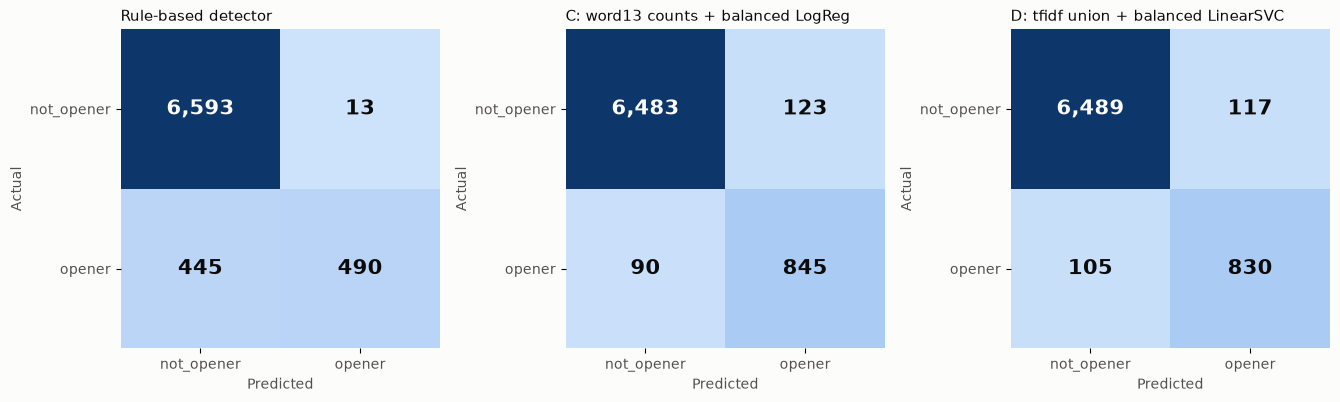

In [32]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from utils.colors import SEQ_BLUES, CHROME

ramp = [SEQ_BLUES[k] for k in sorted(SEQ_BLUES)]
seq_cmap = mcolors.LinearSegmentedColormap.from_list("seq_blues", ramp)

def plot_confusion_matrix(ax, actual, predicted, title):
    cm = np.array([
        [((actual == 0) & (predicted == 0)).sum(), ((actual == 0) & (predicted == 1)).sum()],
        [((actual == 1) & (predicted == 0)).sum(), ((actual == 1) & (predicted == 1)).sum()],
    ])
    ax.imshow(cm, cmap=seq_cmap, vmin=0)
    labels = ["not_opener", "opener"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, color=CHROME["ink_secondary"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, color=CHROME["ink_secondary"])
    ax.set_xlabel("Predicted", color=CHROME["ink_secondary"])
    ax.set_ylabel("Actual", color=CHROME["ink_secondary"])
    ax.set_title(title, color=CHROME["ink_primary"], fontsize=11, loc="left")
    cm_max = cm.max()
    for i in range(2):
        for j in range(2):
            text_color = CHROME["surface_light"] if cm[i, j] > cm_max * 0.5 else CHROME["ink_primary"]
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color=text_color, fontsize=15, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), facecolor=CHROME["surface_light"])
for ax in axes:
    ax.set_facecolor(CHROME["surface_light"])

actual = cv_pool["is_opener"].to_numpy()
plot_confusion_matrix(axes[0], actual, cv_pool["rule_pred"].to_numpy(), "Rule-based detector")
plot_confusion_matrix(axes[1], actual, oof_by_model["C: word13 counts + balanced LogReg"]["pred"].to_numpy(),
                       "C: word13 counts + balanced LogReg")
plot_confusion_matrix(axes[2], actual, oof_by_model["D: tfidf union + balanced LinearSVC"]["pred"].to_numpy(),
                       "D: tfidf union + balanced LinearSVC")

plt.tight_layout()
plt.show()

### Row-level error table for D and C

Attaches each model's OOF output onto a copy of `cv_pool` (never modifies `cv_pool` itself),
labels every row TP/TN/FP/FN, and adds `distance_to_threshold` -- the score's position relative
to *that row's own fold-specific* selected threshold, not the raw score, since fold-to-fold
score scales differ (Step 2's SVC margins aren't on a shared scale across folds -- this is the
same reason the earlier standalone threshold-tuning cell used distance-to-threshold over raw
score). `absolute_margin` is its unsigned size -- how far a prediction sits from the boundary
that produced it, correct or not. `cv_pool` already carries `protocol_id` natively, so it isn't
re-added here.

In [33]:
def build_error_table(oof_df):
    error_df = cv_pool.copy()
    for column in oof_df.columns:
        error_df[column] = oof_df[column].to_numpy()

    error_df["error_type"] = np.select(
        [
            (error_df["y_true"] == 1) & (error_df["pred"] == 1),
            (error_df["y_true"] == 0) & (error_df["pred"] == 0),
            (error_df["y_true"] == 0) & (error_df["pred"] == 1),
            (error_df["y_true"] == 1) & (error_df["pred"] == 0),
        ],
        ["TP", "TN", "FP", "FN"],
        default="UNSET",
    )
    error_df["distance_to_threshold"] = error_df["oof_score"] - error_df["selected_threshold"]
    error_df["absolute_margin"] = error_df["distance_to_threshold"].abs()

    assert (error_df["error_type"] != "UNSET").all()
    return error_df

errors_by_model = {name: build_error_table(oof) for name, oof in oof_by_model.items()}
for name, error_df in errors_by_model.items():
    print(f"{name:40s} {error_df['error_type'].value_counts().reindex(['TP', 'TN', 'FP', 'FN']).to_dict()}")

D: tfidf union + balanced LinearSVC      {'TP': 830, 'TN': 6489, 'FP': 117, 'FN': 105}
E: tfidf union + unweighted LinearSVC    {'TP': 834, 'TN': 6486, 'FP': 120, 'FN': 101}
C: word13 counts + balanced LogReg       {'TP': 845, 'TN': 6483, 'FP': 123, 'FN': 90}


### Ranked error-review table for D: false positives and false negatives

Split into four sets, all from `error_D` (already built above -- no rerun): the most extreme FP
and FN first (largest `distance_to_threshold` for FP, most negative for FN -- furthest past that
fold's decision boundary in the wrong direction), then the borderline cases from each (smallest
`absolute_margin`, right at the boundary).

Correction on earlier wording: `head(N_REVIEW)` here selects the most extreme errors by
distance, not a calibrated confidence ranking. LinearSVC's `decision_function` is a signed
distance from the separating hyperplane, not a probability, and each outer fold fits its own
separate model on different training data, so scores aren't on a shared scale across folds
either -- that's exactly why this uses `distance_to_threshold` (relative to that fold's own
selected threshold) rather than raw `oof_score`. Use the distance ranking as a review-
prioritization aid -- which errors to read first -- not a confidence claim about the model.

Errors far from the boundary still point toward a systematic pattern worth investigating -- a
feature failure, a mislabeled case, atypical phrasing; borderline ones toward threshold
sensitivity or genuine annotation-rule ambiguity. This is the first thing to read before any
state/length/protocol/model breakdown -- it says which kind of mistake D is actually making.

In [34]:
REVIEW_MODELS = [
    "D: tfidf union + balanced LinearSVC",
    "C: word13 counts + balanced LogReg",
]  # add/remove candidates here -- distance_to_threshold/absolute_margin mean the same thing
   # for any linear model's raw score, so this loop needs no per-model special-casing

REVIEW_COLS = [
    "protocol_id", "state", "n_paragraphs", "outer_fold", "selected_C", "selected_threshold",
    "y_true", "pred", "error_type", "oof_score", "distance_to_threshold", "absolute_margin",
    "content",
]
N_REVIEW = 20

def print_reviewable(df, label):
    """One readable text block per row -- a dataframe table is the wrong format for reading
    prose: even with no column-width truncation, the content column is squeezed next to a
    dozen metadata columns and wraps awkwardly. This prints each contribution's full text on
    its own, with a compact metadata header above it."""
    print(f"\n{'='*90}\n{label} -- {len(df)} shown\n{'='*90}")
    for _, row in df.iterrows():
        print(f"\nprotocol {row['protocol_id']} | state {row['state']} | fold {row['outer_fold']} | "
              f"n_paragraphs={row['n_paragraphs']} | C={row['selected_C']}")
        print(f"score={row['oof_score']:.3f}  threshold={row['selected_threshold']:.3f}  "
              f"distance={row['distance_to_threshold']:+.3f}  margin={row['absolute_margin']:.3f}")
        print("-" * 60)
        print(row["content"])

for review_model in REVIEW_MODELS:
    error_df = errors_by_model[review_model]
    label = review_model.split(":")[0]  # e.g. "D" out of "D: tfidf union + balanced LinearSVC"

    fp_review = (
        error_df.loc[error_df["error_type"] == "FP", REVIEW_COLS]
                .sort_values("distance_to_threshold", ascending=False)
    )
    fn_review = (
        error_df.loc[error_df["error_type"] == "FN", REVIEW_COLS]
                .sort_values("distance_to_threshold", ascending=True)
    )
    borderline_fp = (
        error_df.loc[error_df["error_type"] == "FP", REVIEW_COLS]
                .sort_values("absolute_margin")
                .head(N_REVIEW)
    )
    borderline_fn = (
        error_df.loc[error_df["error_type"] == "FN", REVIEW_COLS]
                .sort_values("absolute_margin")
                .head(N_REVIEW)
    )

    print_reviewable(fp_review.head(N_REVIEW), f"{label} -- most extreme false positives (furthest past threshold)")
    print_reviewable(fn_review.head(N_REVIEW), f"{label} -- most extreme false negatives (furthest past threshold)")
    print_reviewable(borderline_fp, f"{label} -- borderline false positives (closest to threshold)")
    print_reviewable(borderline_fn, f"{label} -- borderline false negatives (closest to threshold)")


D -- most extreme false positives (furthest past threshold) -- 20 shown

protocol by_17_100 | state by | fold 4 | n_paragraphs=1050 | C=10.0
score=1.834  threshold=0.138  distance=+1.696  margin=1.696
------------------------------------------------------------
Danke schön. – Weitere Wortmeldungen liegen mir nicht vor. Damit ist die Aussprache geschlossen. Wir kommen jetzt zur Abstimmung.
Der federführende Ausschuss für Arbeit und Soziales, Jugend, Familie und Integration empfiehlt die Ablehnung des Antrags. Wer entgegen dem Ausschussvotum dem Antrag zustimmen möchte, den bitte ich jetzt um sein Handzeichen. – Das sind die SPD-Fraktion, die FREIEN WÄHLER und das BÜNDNIS 90/DIE GRÜNEN. Gegenstimmen! – Das ist die CSU-Fraktion. Stimmenthaltungen? – Keine Stimmenthaltungen. Damit ist der Antrag abgelehnt.
Ich gebe nun noch das Ergebnis der namentlichen Abstimmungen bekannt; zunächst zum Dringlichkeitsantrag der Abgeordneten Thomas Kreuzer, Josef Zellmeier, Petra Guttenberger und anderer 


C -- most extreme false positives (furthest past threshold) -- 20 shown

protocol by_17_100 | state by | fold 4 | n_paragraphs=1050 | C=1.0
score=267.727  threshold=-1.046  distance=+268.773  margin=268.773
------------------------------------------------------------
Danke schön. – Weitere Wortmeldungen liegen mir nicht vor. Damit ist die Aussprache geschlossen. Wir kommen jetzt zur Abstimmung.
Der federführende Ausschuss für Arbeit und Soziales, Jugend, Familie und Integration empfiehlt die Ablehnung des Antrags. Wer entgegen dem Ausschussvotum dem Antrag zustimmen möchte, den bitte ich jetzt um sein Handzeichen. – Das sind die SPD-Fraktion, die FREIEN WÄHLER und das BÜNDNIS 90/DIE GRÜNEN. Gegenstimmen! – Das ist die CSU-Fraktion. Stimmenthaltungen? – Keine Stimmenthaltungen. Damit ist der Antrag abgelehnt.
Ich gebe nun noch das Ergebnis der namentlichen Abstimmungen bekannt; zunächst zum Dringlichkeitsantrag der Abgeordneten Thomas Kreuzer, Josef Zellmeier, Petra Guttenberger und an

## Miss rate by TOP document type (descriptive only)

For each document type, the share of true opener blocks that C and D miss, using their
out-of-fold predictions on the frozen folds.

**Read this as a rough pointer, not as evidence about document types.** `type` is annotation
metadata, not a clean property of a block:

- It is recorded on whichever row prints it (often a citation line after the opener), and a
  block collects the types of all its rows. about a fifth of opener blocks (22%) carry more than one document type,
  partly because the block cites several documents, partly because the `nsc` join merged two
  openers into one block. Each block is counted once per type, so bars overlap and don't sum
  to the opener total.
- The vocabulary is not uniform across states and the two annotation samples (Anfrage vs.
  Mündliche Anfrage, Bericht vs. Beschlussempfehlung, HB joint items), and the pending label
  fixes are not applied yet.
- Type is confounded with state and session format: Anfrage is mostly the Fragestunde, which
  is concentrated in a few states with their own phrasing. A high miss rate for a type can
  therefore reflect a state convention or block length rather than the document type.
- Several groups are small; no uncertainty is shown.

Normalized first: `Mündliche Anfrage` → `Anfrage`, `Dringlicher Antrag` →
`Dringlichkeitsantrag`. `Aktuelle Stunde`, `Aktuelle Debatte` and `Fragestunde` are session
formats, not document types, so they are dropped from the labels; an opener with only a format
tag goes to "(format tag only)", one with no type to "(untyped)".

935 opener blocks, 1240 (block, type) pairs, 204 blocks with more than one type
                       n  miss_rate_C  miss_rate_D
type_group                                        
Beschlussempfehlung   70        0.014        0.000
Große Anfrage         31        0.000        0.000
Änderungsantrag       28        0.036        0.000
Bericht               72        0.014        0.014
Gesetzentwurf        173        0.017        0.017
Antrag               393        0.036        0.023
Abstimmung            32        0.000        0.031
Other                218        0.092        0.101
Anfrage              223        0.242        0.318


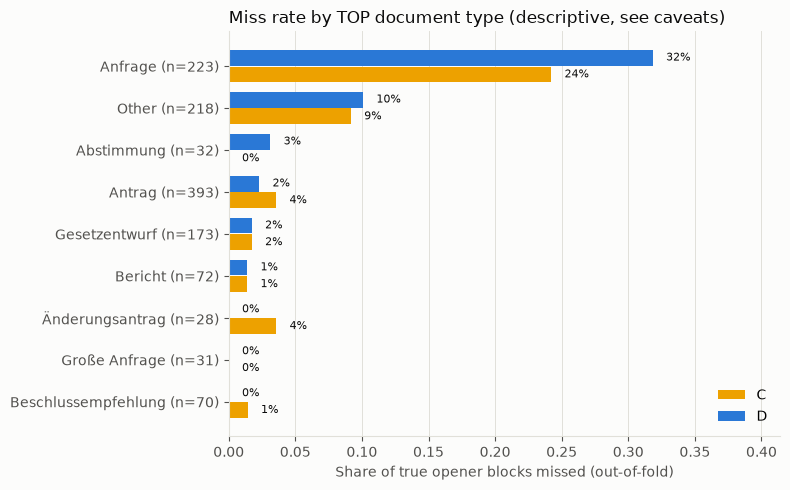

In [35]:
from utils.colors import NAVY, GOLD

TYPE_MAP = {"Mündliche Anfrage": "Anfrage", "Dringlicher Antrag": "Dringlichkeitsantrag"}
FORMAT_TAGS = {"Aktuelle Stunde", "Aktuelle Debatte", "Fragestunde"}
TYPE_MODELS = {"C": "C: word13 counts + balanced LogReg", "D": "D: tfidf union + balanced LinearSVC"}
TOP_K_TYPES = 8

def doc_types(labels):
    docs = list(dict.fromkeys(TYPE_MAP.get(t, t) for t in labels if t not in FORMAT_TAGS))
    if docs:
        return docs
    return ["(format tag only)"] if labels else ["(untyped)"]

openers = cv_pool.loc[cv_pool["is_opener"] == 1, ["types"]].copy()
openers["doc_type"] = openers["types"].apply(doc_types)
for label, name in TYPE_MODELS.items():
    openers[f"missed_{label}"] = errors_by_model[name].loc[openers.index, "pred"] == 0

exploded = openers.explode("doc_type")
top_types = exploded["doc_type"].value_counts().head(TOP_K_TYPES).index
exploded["type_group"] = exploded["doc_type"].where(exploded["doc_type"].isin(top_types), "Other")
type_summary = exploded.groupby("type_group").agg(
    n=("doc_type", "size"), **{f"miss_rate_{label}": (f"missed_{label}", "mean") for label in TYPE_MODELS}
).sort_values("miss_rate_D")
print(f"{len(openers)} opener blocks, {len(exploded)} (block, type) pairs, "
      f"{int((openers['doc_type'].str.len() > 1).sum())} blocks with more than one type")
print(type_summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5), facecolor=CHROME["surface_light"])
ax.set_facecolor(CHROME["surface_light"])
positions = np.arange(len(type_summary))
for offset, (label, color) in zip((-0.2, 0.2), (("C", GOLD), ("D", NAVY))):
    rates = type_summary[f"miss_rate_{label}"]
    ax.barh(positions + offset, rates, height=0.38, color=color, label=label)
    for pos, rate in zip(positions + offset, rates):
        ax.text(rate + 0.01, pos, f"{rate:.0%}", va="center", color=CHROME["ink_primary"], fontsize=8)
ax.set_yticks(positions, [f"{t} (n={n})" for t, n in zip(type_summary.index, type_summary["n"])])
ax.set_xlim(0, type_summary[[f"miss_rate_{label}" for label in TYPE_MODELS]].to_numpy().max() * 1.3)
ax.set_xlabel("Share of true opener blocks missed (out-of-fold)", color=CHROME["ink_secondary"])
ax.set_title("Miss rate by TOP document type (descriptive, see caveats)", loc="left",
             color=CHROME["ink_primary"], fontsize=12)
ax.legend(frameon=False, loc="lower right")
ax.tick_params(colors=CHROME["ink_secondary"])
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(CHROME["gridline"])
ax.xaxis.grid(True, color=CHROME["gridline"], linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Most meaningful predictors of C and D

Each model is refit on the training part of every frozen outer fold, with the parameters its
nested search selected for that fold (`folds_by_model`). For each fold the 20 largest positive
(opener) and 20 largest negative coefficients are collected; a term counts as stable if it
appears in several of the 5 folds. Terms in at least 2 folds are listed.

Coefficients rank terms within one model only. They are not comparable between C (raw counts,
logistic regression) and D (L2-normalized TF-IDF, linear SVM), and D's union mixes word
n-grams `[w]` and character n-grams `[c]` (fragments with word boundaries, e.g. `" auf"`).
A large coefficient means the term shifts the score when present, not that it is frequent or
that it causes the label.

Watch for proper names among the stable opener terms (e.g. an asker who poses many questions
in one protocol): they mean the model memorizes individual MPs from question-heavy protocols,
a protocol-specific signal that won't carry over to unseen protocols.

In [36]:
from collections import Counter

TOP_N = 20
MIN_FOLDS = 2
PREDICTOR_MODELS = ["C: word13 counts + balanced LogReg", "D: tfidf union + balanced LinearSVC"]

def readable(term):
    for prefix, tag in (("word_features__", "[w] "), ("char_features__", "[c] ")):
        if term.startswith(prefix):
            return tag + repr(term[len(prefix):])
    return repr(term)

for name in PREDICTOR_MODELS:
    make_vec, make_clf, _ = shortlist[name]
    params_by_fold = folds_by_model[name].set_index("outer_fold")["selected_params"]
    pos_folds, neg_folds = Counter(), Counter()
    coef_sum = {}
    for fold_i, (train_idx, _) in enumerate(frozen_sgkf.split(X, y, groups), start=1):
        pipe = Pipeline([("vec", make_vec()), ("clf", make_clf(*params_by_fold[fold_i]))])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        coefs = pipe.named_steps["clf"].coef_[0]
        names = pipe.named_steps["vec"].get_feature_names_out()
        order = np.argsort(coefs)
        for counter, top in ((pos_folds, order[-TOP_N:]), (neg_folds, order[:TOP_N])):
            for i in top:
                counter[names[i]] += 1
                coef_sum[names[i]] = coef_sum.get(names[i], 0) + coefs[i]

    print(f"\n{name} -- parameters per fold: {params_by_fold.tolist()}")
    for label, counter, sign in (("opener", pos_folds, -1), ("not-opener", neg_folds, 1)):
        stable = [(t, n) for t, n in counter.items() if n >= MIN_FOLDS]
        stable.sort(key=lambda tn: (-tn[1], sign * coef_sum[tn[0]] / tn[1]))
        print(f"  {label}-predicting terms, top {TOP_N} in >= {MIN_FOLDS} of 5 folds "
              f"({len(stable)} of {len(counter)} terms):")
        for term, n in stable:
            print(f"    {readable(term):40s} {n}/5 folds, avg coef={coef_sum[term] / n:+.3f}")


C: word13 counts + balanced LogReg -- parameters per fold: [(3.0,), (3.0,), (3.0,), (1.0,), (0.3,)]
  opener-predicting terms, top 20 in >= 2 of 5 folds (23 of 31 terms):
    'frage'                                  5/5 folds, avg coef=+2.750
    'tagesordnungspunkt'                     5/5 folds, avg coef=+1.581
    'anfrage'                                5/5 folds, avg coef=+1.367
    'rufe'                                   5/5 folds, avg coef=+1.256
    'kommen'                                 5/5 folds, avg coef=+1.127
    'zu stellen'                             5/5 folds, avg coef=+1.061
    'ich rufe'                               5/5 folds, avg coef=+0.961
    'nächste frage'                          4/5 folds, avg coef=+1.400
    'herr krauß'                             4/5 folds, avg coef=+1.348
    'nr'                                     4/5 folds, avg coef=+1.340
    'krauß'                                  4/5 folds, avg coef=+1.326
    'bitte frage nr'                


D: tfidf union + balanced LinearSVC -- parameters per fold: [(10.0,), (10.0,), (10.0,), (10.0,), (1.0,)]
  opener-predicting terms, top 20 in >= 2 of 5 folds (27 of 36 terms):
    [w] 'rufe'                               5/5 folds, avg coef=+1.142
    [w] 'ich rufe'                           5/5 folds, avg coef=+1.017
    [w] 'drs'                                5/5 folds, avg coef=+0.999
    [w] 'zu stellen'                         5/5 folds, avg coef=+0.794
    [w] 'nächste frage'                      4/5 folds, avg coef=+1.525
    [c] ' frag'                              4/5 folds, avg coef=+0.915
    [w] 'frage frau'                         4/5 folds, avg coef=+0.882
    [w] 'kommen zur frage'                   4/5 folds, avg coef=+0.852
    [w] 'die frage'                          4/5 folds, avg coef=+0.847
    [w] 'zur frage'                          4/5 folds, avg coef=+0.792
    [w] 'kommen'                             4/5 folds, avg coef=+0.763
    [c] 'en '                  

## Fine-tuned German encoder: ModernGBERT with neighbouring-block context

Replaces the earlier gbert/parlbert trial, which truncated at 128 tokens (only 30% of
openers fit), used a fixed 0.5 cutoff and unfrozen folds.

- Model: `LSX-UniWue/ModernGBERT_134M` (German-only ModernBERT, 8,192-token context).
  `MAX_LENGTH = 1024` fits 94% of openers alone and 97% of blocks with context.
- Input: the block, plus the previous and next block of the same protocol as a second
  segment ("Davor: … / Danach: …"). That gives the model the "N Zusatzfragen möglich"
  line before a question call, or the vote before a TOP call. `USE_CONTEXT = False`
  runs the block alone.
- Same evaluation as C and D: the frozen outer folds. Per outer fold, frozen inner fold 1
  is held out for early stopping (best of up to 4 epochs) and for the macro-F1 threshold,
  so the outer fold is scored once, with nothing tuned on it. Scores are the logit
  margin, so `distance_to_threshold` means the same as for the linear models.
- Batches are grouped by length under a token budget, so short blocks (median ~90 tokens
  with context) don't pay for the long ones.
- Memory: batches are padded to multiples of 64 and the MPS cache is released every 10
  batches. Without that, the allocator kept the buffers of every batch shape, grew past 26 GB
  within one epoch and pushed the Mac into swap (training ran ~20x slower).
- Runtime: ~6 min per training epoch plus ~2.5 min to score the inner fold, so ~35 min per
  fold and ~3 h for all five (`BERT_FOLDS = None`; e.g. `[1]` for a single fold). Results go
  to `bert_oof_checkpoint.pkl`, separate from the linear models' checkpoint, and are reused
  only if config, labels and folds still match.
- The five folds were trained in a separate, fresh Python process running this same cell (`run_bert_cv.py` next to
  this notebook: `norm_env/bin/python measurement/top_change/run_bert_cv.py`), because inside this kernel -- after all the cells above -- the
  combined memory pushed the Mac into swap and training stalled. This cell then loads the
  result; the checkpoint is only accepted if config, labels and frozen folds match, and the
  stored training log is printed.

In [37]:
import copy
import time

import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

BERT_NAME = "LSX-UniWue/ModernGBERT_134M"
BERT_MODEL_KEY = "G: ModernGBERT_134M + context"
USE_CONTEXT = True        # False: the block alone
MAX_LENGTH = 1024         # fits 94% of openers alone, 97% of blocks with context
TOKENS_PER_BATCH = 8192   # length-bucketed batches, padded only to the longest block in each
MAX_BATCH_SIZE = 32
MAX_EPOCHS = 4            # best epoch picked on the inner validation fold
LR = 3e-5
BERT_SEED = 917
BERT_FOLDS = None         # None runs all five; e.g. [1] for a quick runtime check
BERT_CHECKPOINT_PATH = Path("bert_oof_checkpoint.pkl")
USE_BERT_CHECKPOINT = True

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
training_log = []  # stored in the checkpoint and printed again when it's loaded

def log(message):
    print(message, flush=True)
    training_log.append(message)
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
Y = y.astype(int).to_numpy()

# Context: the previous and next block of the same protocol (cv_pool keeps protocol order).
# "longest_first" trims whichever side is longer, so a short block keeps all of its own text.
prev_block = cv_pool.groupby("protocol_id")["content"].shift(1).fillna("")
next_block = cv_pool.groupby("protocol_id")["content"].shift(-1).fillna("")
context = ("Davor: " + prev_block + "\nDanach: " + next_block).tolist() if USE_CONTEXT else None
encodings = tokenizer(X.tolist(), context, truncation="longest_first", max_length=MAX_LENGTH)
lengths = np.array([len(ids) for ids in encodings["input_ids"]])
print(f"device: {device}; tokens per unit: median {int(np.median(lengths))}, "
      f"95th pct {int(np.percentile(lengths, 95))}, at cap {100 * (lengths == MAX_LENGTH).mean():.1f}%")


def make_batches(idx, rng=None):
    """Length-sorted batches under a token budget; shuffled batch order when training."""
    idx = np.asarray(idx)[np.argsort(lengths[idx], kind="stable")]
    batches, current = [], []
    for i in idx:
        too_long = len(current) > 0 and (len(current) + 1) * lengths[i] > TOKENS_PER_BATCH
        if too_long or len(current) == MAX_BATCH_SIZE:
            batches.append(current)
            current = []
        current.append(i)
    if current:
        batches.append(current)
    if rng is not None:
        rng.shuffle(batches)
    return batches


def collate(batch_idx):
    """Pad to a multiple of 64, so the batches come in far fewer distinct shapes."""
    features = [{"input_ids": encodings["input_ids"][i], "attention_mask": encodings["attention_mask"][i]}
                for i in batch_idx]
    return tokenizer.pad(features, pad_to_multiple_of=64, return_tensors="pt").to(device)


def free_gpu_cache():
    """The MPS allocator keeps the buffers of every batch shape it has seen; without releasing
    them its memory grew past 26 GB within one epoch, pushed the Mac into swap and slowed
    training about 20-fold. Releasing every few batches keeps it at ~3 GB at the same speed."""
    if device.type == "mps":
        torch.mps.empty_cache()


@torch.no_grad()
def predict_margins(model, idx):
    """Logit margin (positive minus negative class), in the order of `idx`."""
    model.eval()
    position = {i: k for k, i in enumerate(idx)}
    out = np.empty(len(idx))
    for k, batch_idx in enumerate(make_batches(idx), start=1):
        logits = model(**collate(batch_idx)).logits.float()
        for i, margin in zip(batch_idx, (logits[:, 1] - logits[:, 0]).cpu().numpy()):
            out[position[i]] = margin
        if k % 10 == 0:
            free_gpu_cache()
    free_gpu_cache()
    return out


def train_one_fold(train_idx, val_idx):
    """Fine-tune on train_idx; after each epoch pick the macro-F1-best threshold on val_idx and
    keep the epoch whose best threshold scores highest. val_idx is the frozen inner fold, never
    the outer validation fold."""
    torch.manual_seed(BERT_SEED)
    rng = np.random.default_rng(BERT_SEED)
    model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=2).to(device)
    counts = np.bincount(Y[train_idx], minlength=2)
    class_weights = torch.tensor(len(train_idx) / (2.0 * counts), dtype=torch.float32, device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    n_steps = MAX_EPOCHS * len(make_batches(train_idx))
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.06 * n_steps), n_steps)
    best = {"score": -1.0}
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for k, batch_idx in enumerate(make_batches(train_idx, rng), start=1):
            logits = model(**collate(batch_idx)).logits.float()
            labels = torch.tensor(Y[batch_idx], device=device)
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            if k % 10 == 0:
                free_gpu_cache()
        margins = predict_margins(model, val_idx)
        candidates = np.unique(margins)
        scores = _threshold_scores(Y[val_idx], margins, candidates, PRIMARY_METRIC)
        i_best = int(np.argmax(scores))
        log(f"    epoch {epoch}: inner {PRIMARY_METRIC}={scores[i_best]:.3f}")
        if scores[i_best] > best["score"]:
            best = {"score": scores[i_best], "threshold": candidates[i_best], "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
    model.load_state_dict(best["state"])
    return model, best


config = {"model": BERT_NAME, "context": USE_CONTEXT, "max_length": MAX_LENGTH, "max_epochs": MAX_EPOCHS,
          "lr": LR, "seed": BERT_SEED, "tokens_per_batch": TOKENS_PER_BATCH}
wanted_folds = sorted(fold_assignment["outer_fold"].unique()) if BERT_FOLDS is None else sorted(BERT_FOLDS)

def bert_checkpoint_usable(checkpoint):
    """Reuse a checkpoint only if it was made with this config, covers the requested folds, and
    matches the current cv_pool row for row (labels and frozen outer folds)."""
    oof = checkpoint["oof"]
    return (checkpoint["config"] == config
            and sorted(checkpoint["folds_run"]) == wanted_folds
            and len(oof) == len(X)
            and (oof["y_true"].to_numpy() == Y).all()
            and (oof.loc[oof["outer_fold"] > 0, "outer_fold"].to_numpy()
                 == groups.map(fold_assignment["outer_fold"]).to_numpy()[oof["outer_fold"].to_numpy() > 0]).all())

bert_checkpoint = None
if USE_BERT_CHECKPOINT and BERT_CHECKPOINT_PATH.exists():
    with open(BERT_CHECKPOINT_PATH, "rb") as f:
        bert_checkpoint = pickle.load(f)
    if not bert_checkpoint_usable(bert_checkpoint):
        print(f"{BERT_CHECKPOINT_PATH} doesn't match the current config/data/folds -- retraining")
        bert_checkpoint = None

if bert_checkpoint is not None:
    bert_oof = bert_checkpoint["oof"]
    print(f"Loaded {BERT_CHECKPOINT_PATH}: folds {bert_checkpoint['folds_run']}, config {bert_checkpoint['config']}")
    print("Training log:\n" + "\n".join(bert_checkpoint.get("log", [])))
else:
    bert_oof = pd.DataFrame({
        "model": BERT_MODEL_KEY, "y_true": Y, "oof_score": np.nan, "pred_default": -1, "pred": -1,
        "outer_fold": -1, "selected_C": np.nan, "selected_threshold": np.nan, "best_epoch": -1,
    }, index=X.index)
    folds_run = []
    for fold_i, (train_idx, val_idx) in enumerate(frozen_sgkf.split(X, y, groups), start=1):
        if fold_i not in wanted_folds:
            continue
        start = time.time()
        inner_fold = groups.iloc[train_idx].map(frozen_inner[fold_i]).to_numpy()
        inner_train, inner_val = train_idx[inner_fold != 1], train_idx[inner_fold == 1]
        log(f"fold {fold_i}: train {len(inner_train)}, inner val {len(inner_val)}, outer val {len(val_idx)}")
        model, best = train_one_fold(inner_train, inner_val)
        margins = predict_margins(model, val_idx)
        rows = bert_oof.index[val_idx]
        bert_oof.loc[rows, "oof_score"] = margins
        bert_oof.loc[rows, "pred_default"] = (margins >= 0).astype(int)
        bert_oof.loc[rows, "pred"] = (margins >= best["threshold"]).astype(int)
        bert_oof.loc[rows, "outer_fold"] = fold_i
        bert_oof.loc[rows, "selected_threshold"] = best["threshold"]
        bert_oof.loc[rows, "best_epoch"] = best["epoch"]
        folds_run.append(fold_i)
        log(f"fold {fold_i}: best epoch {best['epoch']}, threshold {best['threshold']:.3f}, "
            f"{(time.time() - start) / 60:.1f} min")
        del model
        free_gpu_cache()
    with open(BERT_CHECKPOINT_PATH, "wb") as f:
        pickle.dump({"oof": bert_oof, "folds_run": folds_run, "config": config, "log": training_log}, f)
    print(f"Saved {BERT_CHECKPOINT_PATH} (folds {folds_run})")

device: mps; tokens per unit: median 83, 95th pct 736, at cap 2.8%
Loaded bert_oof_checkpoint.pkl: folds [1, 2, 3, 4, 5], config {'model': 'LSX-UniWue/ModernGBERT_134M', 'context': True, 'max_length': 1024, 'max_epochs': 4, 'lr': 3e-05, 'seed': 917, 'tokens_per_batch': 8192}
Training log:
fold 1: train 4075, inner val 2014, outer val 1452
    epoch 1: inner macro_f1=0.900
    epoch 2: inner macro_f1=0.925
    epoch 3: inner macro_f1=0.940
    epoch 4: inner macro_f1=0.946
fold 1: best epoch 4, threshold -0.794, 29.0 min
fold 2: train 3994, inner val 2022, outer val 1525
    epoch 1: inner macro_f1=0.904
    epoch 2: inner macro_f1=0.977
    epoch 3: inner macro_f1=0.971
    epoch 4: inner macro_f1=0.975
fold 2: best epoch 2, threshold 2.265, 30.8 min
fold 3: train 4109, inner val 1921, outer val 1511
    epoch 1: inner macro_f1=0.945
    epoch 2: inner macro_f1=0.958
    epoch 3: inner macro_f1=0.977
    epoch 4: inner macro_f1=0.977
fold 3: best epoch 3, threshold 2.137, 29.1 min
fold

In [38]:
def is_question_opener_type(types):
    """Fragestunde question openers: an Anfrage type that is not a Große Anfrage."""
    return any("Anfrage" in t and "Große" not in t for t in types)

question_opener = cv_pool["types"].apply(is_question_opener_type).to_numpy() & (Y == 1)
compare = {
    "C": oof_by_model["C: word13 counts + balanced LogReg"],
    "D": oof_by_model["D: tfidf union + balanced LinearSVC"],
    "G (BERT)": bert_oof,
}
done_folds = sorted(bert_oof.loc[bert_oof["outer_fold"] > 0, "outer_fold"].unique())

rows = []
for label, oof in compare.items():
    for fold_i in done_folds:
        in_fold = (bert_oof["outer_fold"] == fold_i).to_numpy()
        y_fold, pred, score = Y[in_fold], oof["pred"].to_numpy()[in_fold], oof["oof_score"].to_numpy()[in_fold]
        p_c, r_c, f_c, _ = precision_recall_fscore_support(y_fold, pred, labels=[0, 1], zero_division=0)
        q_fold = question_opener[in_fold]
        rows.append({"model": label, "fold": fold_i, "F1": f_c[1], "P": p_c[1], "R": r_c[1],
                     "Macro-F1": (f_c[0] + f_c[1]) / 2, "MCC": matthews_corrcoef(y_fold, pred),
                     "ROC-AUC": roc_auc_score(y_fold, score), "PR-AUC": average_precision_score(y_fold, score),
                     "question-opener R": pred[q_fold].mean() if q_fold.any() else np.nan})
per_fold = pd.DataFrame(rows)
print(f"Folds run for BERT: {done_folds}; C and D scored on the same folds")
print(per_fold.groupby("model", sort=False).mean(numeric_only=True).drop(columns="fold").round(3).to_string())
if len(done_folds) > 1:
    print("\nper-fold F1:")
    print(per_fold.pivot(index="fold", columns="model", values="F1").round(3).to_string())

if len(done_folds) == 5:
    errors_by_model[BERT_MODEL_KEY] = build_error_table(bert_oof.drop(columns="best_epoch"))
    print(f"\nAdded '{BERT_MODEL_KEY}' to errors_by_model -- add it to REVIEW_MODELS to review its errors")

Folds run for BERT: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]; C and D scored on the same folds
             F1      P      R  Macro-F1    MCC  ROC-AUC  PR-AUC  question-opener R
model                                                                             
C         0.886  0.874  0.908     0.935  0.873    0.983   0.924              0.829
D         0.881  0.879  0.892     0.932  0.867    0.990   0.948              0.755
G (BERT)  0.917  0.932  0.907     0.953  0.907    0.990   0.965              0.803

per-fold F1:
model      C      D  G (BERT)
fold                         
1      0.891  0.862     0.913
2      0.958  0.938     0.972
3      0.881  0.903     0.932
4      0.900  0.898     0.912
5      0.801  0.804     0.856

Added 'G: ModernGBERT_134M + context' to errors_by_model -- add it to REVIEW_MODELS to review its errors


### Confusion matrices: rule-based detector, C, D and BERT

Out-of-fold predictions on the same frozen folds, each at its own fold-wise tuned threshold.

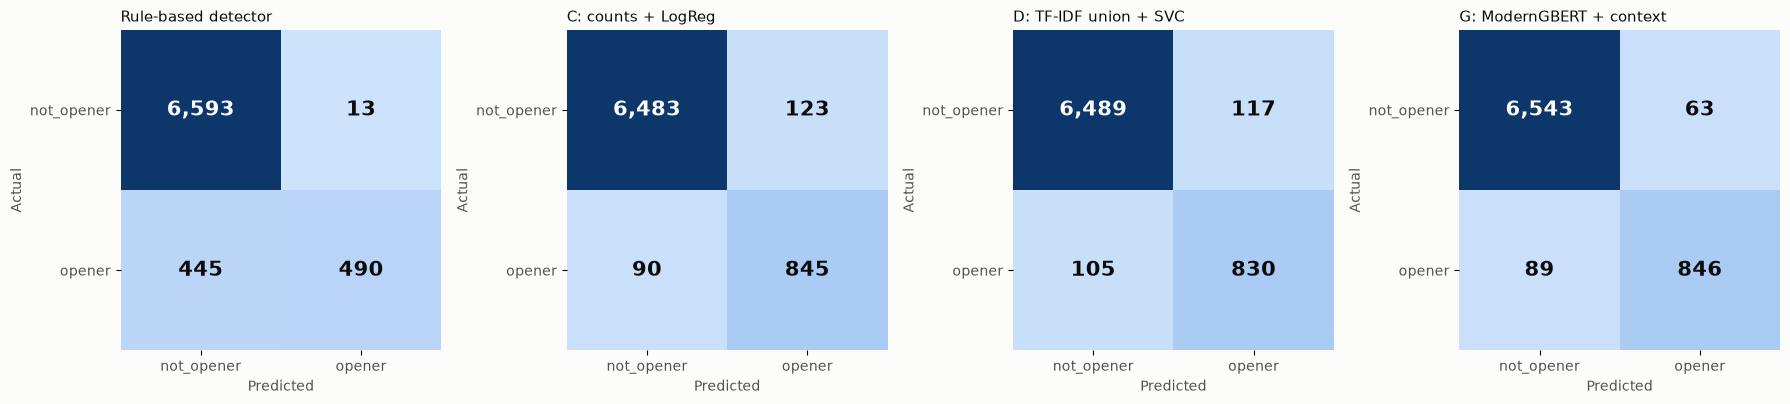

In [39]:
C_NAME = "C: word13 counts + balanced LogReg"
D_NAME = "D: tfidf union + balanced LinearSVC"

bert_done = (bert_oof["outer_fold"] > 0).to_numpy()
if not bert_done.all():
    print(f"BERT covers {bert_done.sum()} of {len(bert_done)} rows (folds {done_folds}); "
          "all four matrices are restricted to those rows")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), facecolor=CHROME["surface_light"])
for ax in axes:
    ax.set_facecolor(CHROME["surface_light"])
actual = cv_pool["is_opener"].to_numpy()[bert_done]
plot_confusion_matrix(axes[0], actual, cv_pool["rule_pred"].to_numpy()[bert_done], "Rule-based detector")
plot_confusion_matrix(axes[1], actual, oof_by_model[C_NAME]["pred"].to_numpy()[bert_done], "C: counts + LogReg")
plot_confusion_matrix(axes[2], actual, oof_by_model[D_NAME]["pred"].to_numpy()[bert_done], "D: TF-IDF union + SVC")
plot_confusion_matrix(axes[3], actual, bert_oof["pred"].to_numpy()[bert_done], "G: ModernGBERT + context")
plt.tight_layout()
plt.show()

### BERT error analysis

Compares BERT's errors with C's and D's row by row: which errors all three share (label, segmentation
and corpus problems no model change touches), which BERT fixes, and which are new with BERT. Then
question-opener recall, errors by block length and state, and the same ranked review lists as for C
and D, plus the most confident "fixed by BERT" and "new with BERT" cases.

In [40]:
assert BERT_MODEL_KEY in errors_by_model, "run all five BERT folds first (BERT_FOLDS = None)"

errors_G = errors_by_model[BERT_MODEL_KEY]
compare_err = pd.DataFrame({
    "C": errors_by_model[C_NAME]["error_type"], "D": errors_by_model[D_NAME]["error_type"],
    "G": errors_G["error_type"], "question_opener": question_opener,
    "state": cv_pool["state"], "n_paragraphs": cv_pool["n_paragraphs"],
})
print("Error counts:")
print(pd.DataFrame({m: compare_err[m].value_counts() for m in "CDG"}).reindex(["TP", "TN", "FP", "FN"]).T.to_string())

for error in ("FP", "FN"):
    wrong = {m: compare_err[m] == error for m in "CDG"}
    print(f"\n{error}: all three {int((wrong['C'] & wrong['D'] & wrong['G']).sum())} | "
          f"C and D but not G (fixed by BERT) {int((wrong['C'] & wrong['D'] & ~wrong['G']).sum())} | "
          f"G only (new with BERT) {int((wrong['G'] & ~wrong['C'] & ~wrong['D']).sum())} | "
          f"G and exactly one of C/D {int((wrong['G'] & (wrong['C'] ^ wrong['D'])).sum())}")

n_questions = int(question_opener.sum())
print(f"\nQuestion openers missed (of {n_questions}): " +
      ", ".join(f"{m} {int(((compare_err[m] == 'FN') & compare_err['question_opener']).sum())}" for m in "CDG"))

length_bucket = pd.cut(compare_err["n_paragraphs"], [0, 1, 3, 10, np.inf], labels=["1", "2-3", "4-10", ">10"])
for error in ("FP", "FN"):
    print(f"\n{error} by block length (paragraphs):")
    print(pd.DataFrame({m: length_bucket[compare_err[m] == error].value_counts() for m in "CDG"})
          .reindex(["1", "2-3", "4-10", ">10"]).T.to_string())
print("\nErrors (FP + FN) by state:")
print(pd.DataFrame({m: compare_err.loc[compare_err[m].isin(["FP", "FN"]), "state"].value_counts() for m in "CDG"})
      .fillna(0).astype(int).sort_values("G", ascending=False).T.to_string())

# ranked review lists for BERT, same format as the review cell for C and D above
fp_review_G = errors_G.loc[errors_G["error_type"] == "FP", REVIEW_COLS].sort_values("distance_to_threshold", ascending=False)
fn_review_G = errors_G.loc[errors_G["error_type"] == "FN", REVIEW_COLS].sort_values("distance_to_threshold")
print_reviewable(fp_review_G.head(N_REVIEW), "G -- most extreme false positives (furthest past threshold)")
print_reviewable(fn_review_G.head(N_REVIEW), "G -- most extreme false negatives (furthest past threshold)")

fixed = (compare_err["C"].isin(["FP", "FN"]) & compare_err["D"].isin(["FP", "FN"])
         & compare_err["G"].isin(["TP", "TN"]))
new = (compare_err["G"].isin(["FP", "FN"]) & compare_err["C"].isin(["TP", "TN"])
       & compare_err["D"].isin(["TP", "TN"]))
print_reviewable(errors_G.loc[fixed, REVIEW_COLS].sort_values("absolute_margin", ascending=False).head(10),
                 "Wrong in C and D, right in G (fixed by BERT), most confident first")
print_reviewable(errors_G.loc[new, REVIEW_COLS].sort_values("absolute_margin", ascending=False).head(10),
                 "Right in C and D, wrong in G (new with BERT), most confident first")

Error counts:
    TP    TN   FP   FN
C  845  6483  123   90
D  830  6489  117  105
G  846  6543   63   89

FP: all three 38 | C and D but not G (fixed by BERT) 44 | G only (new with BERT) 14 | G and exactly one of C/D 11

FN: all three 44 | C and D but not G (fixed by BERT) 26 | G only (new with BERT) 24 | G and exactly one of C/D 21

Question openers missed (of 226): C 54, D 71, G 55

FP by block length (paragraphs):
n_paragraphs   1  2-3  4-10  >10
C             28   28    48   19
D             25   23    44   25
G             10   12    23   18

FN by block length (paragraphs):
n_paragraphs   1  2-3  4-10  >10
C             33   27    19   11
D             36   38    23    8
G             33   25    22    9

Errors (FP + FN) by state:
state  be  sn  by  mv  ni  th  he  st  hh  nw  rp  sh  bw  hb  sl  bb
C      30  36  18  15  10  21  15  20   4   6   9   5   4   6   5   9
D      39  38  16  16   9  17  17  10   3   4   7  10   4   7  11  14
G      29  26  15  11  10  10   9   8   6 

### Reading the BERT results (run of 2026-09-26)

**BERT is the best model so far, mainly through precision.** Mean over the frozen folds:
F1 0.917 (C 0.886, D 0.881), precision 0.932 (0.874 / 0.879), recall 0.907 (≈ C's 0.908),
MCC 0.907, PR-AUC 0.965. It beats the better of C and D in every one of the five folds
(per-fold F1 +0.01 to +0.05), so unlike C vs. D the difference is consistent across folds,
not fold noise. False positives are halved (63 vs. 117-123); misses stay at C's level (89 vs. 90).

**What it fixes.** 44 FPs and 26 FNs that both C and D get wrong are right in BERT; only 14 FPs
and 24 FNs are new. FPs drop at every block length (one-paragraph blocks: 10 vs. 25-28). Among
the most confident fixes are speaker calls inside a debate ("Dann kommen wir jetzt zur Debatte
der Fraktionen. - Für die SPD-Fraktion ist zuerst einmal Frau Pähle an der Reihe.", st_8_27)
and question calls that name their subject or come in the same state's usual phrasing (BB
"Die Frage 919 (Aktivitäten der Landesregierung zum Oderausbau) wird von … gestellt", ST "Die
nächste Frage kommt von Herrn Lizureck."). By state, errors fall most in BB (C/D 9/14 → 1), TH,
HE, SN, ST and MV; BE improves only against D (39 → 29; C 30).

**What it doesn't fix.**
- The shared core: 38 FPs and 44 FNs are wrong in all three models. Several of BERT's most
  confident "FPs" are known or probable label errors, i.e. BERT is right: hb_16_51/175 (second
  Anfrage labelled False), th_4_67/1 and st_6_70/1 (v2 Eröffnung missing), and newly
  sn_7_52/1789 ("Wir behandeln nun zwei Kleine Anfragen … Drucksache 7/9689: Geplante Regelung
  zu Mindestabständen …", False). The by_17_100 annex is still an FP.
- Fragestunde calls without subject, now a conflict between states rather than a lack of
  context. BERT's most confident misses are BY/SN calls such as "Nächste Frage: Herr Kollege
  Schieder." (by_15_52) and "Herr Petzold, bitte; Frage Nr. 6." (sn_4_32), while its most
  confident FPs are NI calls such as "Die nächste Frage wird von Herrn Limburg … gestellt."
  (ni_16_37), which are labelled False (follow-up questions in NI's Dringliche Anfragen). The
  same wording means a new question in one state and a follow-up in another, so no text model
  can get both right without knowing the state or the question's position in the sequence.
- Vote blocks in SN ("Ich rufe auf die Drucksache 5/13208, Änderungsantrag …") remain FPs.

**Caveats.** BERT's scores are logit margins, so `distance_to_threshold` is not comparable in
size to C's or D's. The best epoch varies (4, 2, 3, 2, 4) and folds 1 and 5 were still improving
at epoch 4, so a longer schedule might help. Labels are still the pre-fix labels; the known
label errors count against every model.

## Final model evaluation: pending

The held-out test split (1 protocol per state, 16 protocols, 1,708 blocks) is **still unopened**.
Everything in this notebook, including the BERT CV, was decided on `cv_pool` only.

It stays closed while models are still being tried out and before the pending label fixes
(see `top_change_error_analysis.md`). Open it once, for the final model choice only. Two
decisions for that step, from the BERT CV:

- Refit on all of `cv_pool`: early stopping is then done in the CV (best epochs per fold
  4, 2, 3, 2, 4, so e.g. 3 epochs), since no held-out data is left to stop on.
- The threshold: BERT's CV F1 at the default cutoff 0 (0.920 ± 0.032) matches the tuned
  threshold (0.917 ± 0.042), so a full-data refit can use cutoff 0. C's threshold comes
  from the same out-of-fold search as in the nested CV.